# Setting

In [23]:
import pandas as pd
from datetime import datetime

# 買進賣出需要的手續費
fee = {
    "tax_stock": 0.003,  # 買進與賣出各0.003
    "tax_future": 0.00002 * 2,  # 買進與賣出各0.00002
    "fee_stock": 0.001425 * 2,  # 券商手續費公道價，買進與賣出各0.001425
    "fee_future": 0.00002 * 2,  # 各家不大相同，以交易稅計算
    "sliding_price": 0.00001,  # 滑價
}

# 股票清單
data = [
    # ["2308", "台達電", "tw"],
    # ["2317", "鴻海", "tw"],
    # ["2330", "台積電", "tw"],
    # ["2382", "廣達", "tw"],
    # ["2412", "中華電", "tw"],
    # ["2454", "聯發科", "tw"],
    # ["2881", "富邦金", "tw"],
    # ["2882", "國泰金", "tw"],
    # ["2891", "中信金", "tw"],
    # ["6505", "台塑化", "tw"],
    
    # ["3231", "緯創", "tw"],
    # ["2207", "和泰車", "tw"],
    # ["3661", "世芯", "tw"],
    # ["2603", "長榮", "tw"],
    # ["2408", "南亞科", "tw"],
    
    
    # ["AAPL", "Apple Inc.", "us"],
    ["MSFT", "Microsoft", "us"],
    ["NVDA", "Nvidia", "us"],
    ["AMZN", "Amazon inc.", "us"],
    # ["META", "Meta Platforms", "us"],
    # ["GOOGL", "Google", "us"],
    # ["TSLA", "Tesla", "us"],
    # ["AVGO", "Broadcom", "us"],
    # ["BRK", "Berkshire Hathaway", "us"],
    # ["JPM", "JPMorgan Chase", "us"],
    
    # ["BA", "Boeing", "us"],
    # ["MRNA", "Moderna", "us"],
    # ["WMT", "Walmart", "us"],
    # ["UNH", "UnitedHealth Group", "us"],
    # ["DIS", "Disney", "us"],
]

# 指數
index_twii = [
    ["2308", "台達電", "tw"],
    ["2317", "鴻海", "tw"],
    ["2330", "台積電", "tw"],
    ["2382", "廣達", "tw"],
    ["2412", "中華電", "tw"],
    ["2454", "聯發科", "tw"],
    ["2881", "富邦金", "tw"],
    ["2882", "國泰金", "tw"],
    ["2891", "中信金", "tw"],
    ["6505", "台塑化", "tw"],
]

index_spx = [
    ["AAPL", "Apple Inc.", "us"],
    ["MSFT", "Microsoft", "us"],
    ["NVDA", "Nvidia", "us"],
    ["AMZN", "Amazon inc.", "us"],
    ["META", "Meta Platforms", "us"],
    ["GOOGL", "Google", "us"],
    ["TSLA", "Tesla", "us"],
    ["AVGO", "Broadcom", "us"],
    ["BRK", "Berkshire Hathaway", "us"],
    ["JPM", "JPMorgan Chase", "us"],
]

market_index = [
    ["twii", "台灣指數期貨", "tw", index_twii],
    ["spx", "S&P 500", "us", index_spx],
]

date_ranges = [
    ["20210401", "20220331", "2022Q1"], # 2022
    ["20210701", "20220630", "2022Q2"],
    ["20211001", "20220930", "2022Q3"],
    ["20220101", "20221231", "2022Q4"],
    ["20220401", "20230331", "2023Q1"], # 2023
    ["20220701", "20230630", "2023Q2"],
    ["20221001", "20230930", "2023Q3"],
    ["20230101", "20231231", "2023Q4"],
    ["20230401", "20240331", "2024Q1"], # 2024
    ["20230701", "20240630", "2024Q2"],
    ["20231001", "20240930", "2024Q3"],
    ["20240101", "20241231", "2024Q4"],
    
    # ["20240101", "20240115", "test"],
    # ["20231001", "20240131", "2024M1"],
    # ["20231101", "20240229", "2024M2"],
    # ["20231201", "20240331", "2024M3"],
    # ["20240101", "20240430", "2024M4"],
    # ["20240201", "20240531", "2024M5"],
    # ["20240301", "20240630", "2024M6"],
    # ["20240401", "20240731", "2024M7"],
    # ["20240501", "20240831", "2024M8"],
    # ["20240601", "20240930", "2024M9"],
    # ["20240701", "20241031", "2024M10"],
    # ["20240801", "20241130", "2024M11"],
    # ["20240901", "20241231", "2024M12"],
]

# env = {
#     "stock_id" : "NVDA",
#     "stock_name" : "Nvidia",
#     "country" : "us",
#     "start_date" : "20230401",
#     "end_date" : "20240331",
# }

# On(Over Night)抱股過夜作法，正面就持續持有，負面就賣出
# Usable Factor 只跑有用的factor

In [24]:
def get_balance_list(list_rtn, start_price):
    balance = start_price
    list_balance = []
    for rtn in list_rtn:
        balance = balance * (1 + float(rtn))
        list_balance.append(balance)
    return list_balance

In [25]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from math import ceil, sqrt

def display_all_plots(all_plots):
    # 計算需要的子圖行數與列數（接近正方形排列）
    num_plots = len(all_plots)
    cols = ceil(sqrt(num_plots))  # 列數
    rows = ceil(num_plots / cols)  # 行數

    # 創建一個大的畫布
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    # fig.suptitle("Trading Results for All Stocks", fontsize=16, y=0.95)

    # 確保 axes 是一個 2D 陣列
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1 or cols == 1:
        axes = [axes] if rows == 1 else [[ax] for ax in axes]
    else:
        axes = axes.reshape(rows, cols)

    # 在每個子圖中顯示單獨的圖表
    for idx, single_fig in enumerate(all_plots):
        row, col = divmod(idx, cols)
        ax = axes[row][col]
        
        # 從單個圖表中提取並繪製數據
        for line in single_fig.axes[0].get_lines():
            ax.plot(line.get_xdata(), line.get_ydata(), label=line.get_label())
        
        # 設定標題、標籤與圖例
        ax.set_title(single_fig.axes[0].get_title())
        ax.set_xlabel(single_fig.axes[0].get_xlabel())
        ax.set_ylabel(single_fig.axes[0].get_ylabel())
        ax.legend()
        
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # 設置最多顯示 5 個標籤


    # 移除多餘的空白子圖
    for idx in range(num_plots, rows * cols):
        row, col = divmod(idx, cols)
        fig.delaxes(axes[row][col])

    # 調整整體佈局
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)  # 調整總標題的位置
    plt.show()

In [26]:
def cacl_avg(df_stocks_results, wincount=None, ttl_count=None):
    '''
        only return average row
    '''
    
    average_row = pd.DataFrame()
    average_row['tp'] = [df_stocks_results['tp'].sum()]
    average_row['fp'] = [df_stocks_results['fp'].sum()]
    average_row['tn'] = [df_stocks_results['tn'].sum()]
    average_row['fn'] = [df_stocks_results['fn'].sum()]
    average_row['accuracy'] = (average_row['tp'] + average_row['tn']) / (average_row['tp'] + average_row['tn'] + average_row['fp'] + average_row['fn'])
    average_row['precision'] = average_row['tp'] / (average_row['tp'] + average_row['fp'])
    # EV 算法 每個ev成上avail_count 總和後再除上 avail_count 的平均
    average_row['avail_count'] = [df_stocks_results['avail_count'].sum()]
    average_row['pci_avl_count'] = [df_stocks_results['tp'].sum() + df_stocks_results['fp'].sum()]
    average_row['ev'] = (df_stocks_results['ev'].astype(float) * df_stocks_results['avail_count']).sum() / df_stocks_results['avail_count'].sum()
    average_row['precision_ev'] = (df_stocks_results['precision_ev'].astype(float) * (df_stocks_results['tp'] + df_stocks_results['fp'])).sum() / (df_stocks_results['tp'].sum() + df_stocks_results['fp'].sum())
    if ttl_count is None:
        average_row['win B&H'] = None
    else:
        average_row['win B&H'] = round(wincount / ttl_count, 2)
    
    return average_row

In [27]:
# from factor_overnight import FactorON
# for stock in data:
#     env = {
#         "stock_id" : stock[0],
#         "stock_name" : stock[1],
#         "country" : stock[2],
#         "start_date" : "20230401",
#         "end_date" : "20240331",
#         "run_count": "1"
#     }
#     print(env['stock_id'], env['stock_name'], env['country'])

#     eval_module = FactorON(env)
#     eval_module.show_individual(mode=1)
    

In [28]:
# from usable_on import UsableFactorON

# for stock in data:
#     env = {
#         "stock_id" : stock[0],
#         "stock_name" : stock[1],
#         "country" : stock[2],
#         "start_date" : "20230401",
#         "end_date" : "20240331",
#         "run_count": "1"
#     }
#     print(env['stock_id'], env['stock_name'], env['country'])

#     eval_module = UsableFactorON(env)
#     print(eval_module.get_individual(mode=1))
#     a = eval_module.show_sig() 

In [29]:
# # Delete folders named "spx" in the directory tree
# import os
# import shutil

# # Set the root directory for the project
# root_dir = r"/Users/yanyifu/Documents/_Coding/LLM Predict Stock/run_factor/out_stock/Training_result/FactorUsableMix"

# # Walk the directory tree and delete folders named "spx"
# for dirpath, dirnames, filenames in os.walk(root_dir, topdown=False):
#     for dirname in dirnames:
#         if dirname.lower() == "twii":
#             full_path = os.path.join(dirpath, dirname)
#             print(f"Deleting folder: {full_path}")
#             shutil.rmtree(full_path)

In [30]:
from factor_overnight_index import FactorON_Index
from usable_on_index import Index_UsableFactorON

for stock in market_index:
    env = {
        "stock_id" : stock[0],
        "stock_name" : stock[1],
        "country" : stock[2],
        "start_date" : "20240101",
        "end_date" : "20241231",
        "run_count": "1"
    }
    print(env['stock_id'], env['stock_name'], env['country'])

    eval_module = Index_UsableFactorON(env)
    # print(eval_module.get_individual(mode=1))
    a = eval_module.show_sig()

twii 台灣指數期貨 tw
  20210401 =>   1   1   1   1   1   1   1   1 
  20210406 =>   1   1   1  -1   1   1   1   1 
  20210407 =>   1   1   1   1   1   1   1   0 
  20210408 =>   1   1   1   1   1   1   1   1 
  20210409 =>   1   1   1   1   1   0  -1  -1 
  20210412 =>   0   0  -1  -1   1   1  -1  -1 
  20210413 =>   1   0   1  -1   1   1  -1  -1 
  20210414 =>   1   1   1  -1   1   1  -1  -1 
  20210415 =>   0   1   1   1   1   1   0  -1 
  20210416 =>   1   1   1  -1   1   1  -1   0 
  20210419 =>   1   0   1   1   1   1   0   1 
  20210420 =>   1   1   1  -1   1   1  -1   1 
  20210421 =>   1   0   1   1   0   1  -1   1 
  20210422 =>   1  -1   1   0   1   1  -1  -1 
  20210423 =>   1   1   1  -1   1   1  -1  -1 
  20210426 =>   0   0   0   0   0   0   0   0 
  20210427 =>   1   1   1   1   1   1   1   1 
  20210428 =>   1   1   1  -1   1   1  -1  -1 
  20210429 =>   1   1   1   1   1   1   1  -1 
  20210503 =>   1   1   1  -1   1   1   1   0 
  20210504 =>   1   1   1   1   1   1   1  -1

# 7 Factor Daytrade

1
AAPL Apple Inc. us 2024Q1
AAPL Apple Inc. us 2024Q2
AAPL Apple Inc. us 2024Q3
AAPL Apple Inc. us 2024Q4
MSFT Microsoft us 2024Q1
MSFT Microsoft us 2024Q2
MSFT Microsoft us 2024Q3
MSFT Microsoft us 2024Q4
TSLA Tesla us 2024Q1
TSLA Tesla us 2024Q2
TSLA Tesla us 2024Q3
TSLA Tesla us 2024Q4
NVDA Nvidia us 2024Q1
NVDA Nvidia us 2024Q2
NVDA Nvidia us 2024Q3
NVDA Nvidia us 2024Q4
AMZN Amazon inc. us 2024Q1
AMZN Amazon inc. us 2024Q2
AMZN Amazon inc. us 2024Q3
AMZN Amazon inc. us 2024Q4
GOOGL Google us 2024Q1
GOOGL Google us 2024Q2
GOOGL Google us 2024Q3
GOOGL Google us 2024Q4
META Meta Platforms us 2024Q1
META Meta Platforms us 2024Q2
META Meta Platforms us 2024Q3
META Meta Platforms us 2024Q4
BA Boeing us 2024Q1
BA Boeing us 2024Q2
BA Boeing us 2024Q3
BA Boeing us 2024Q4
MRNA Moderna us 2024Q1
MRNA Moderna us 2024Q2
MRNA Moderna us 2024Q3
MRNA Moderna us 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
AAPL - 2024Q1,0.475410,0.433333,-0.000280,0.000042,61,13,17,16,15
AAPL - 2024Q2,0.492063,0.452381,-0.001358,-0.000913,63,19,23,12,9
AAPL - 2024Q3,0.546875,0.615385,-0.000777,0.000695,64,24,15,11,14
AAPL - 2024Q4,0.562500,0.666667,0.001328,0.002856,64,30,15,6,13
MSFT - 2024Q1,0.475410,0.489362,-0.001215,-0.000369,61,23,24,6,8
MSFT - 2024Q2,0.587302,0.630435,-0.000429,-0.000260,63,29,17,8,9
MSFT - 2024Q3,0.484375,0.472222,0.000076,-0.001241,64,17,19,14,14
MSFT - 2024Q4,0.546875,0.585366,0.000769,0.000862,64,24,17,11,12
TSLA - 2024Q1,0.540984,0.454545,0.002148,0.001646,61,5,6,28,22
TSLA - 2024Q2,0.476190,0.200000,-0.002559,-0.008943,63,1,4,29,29


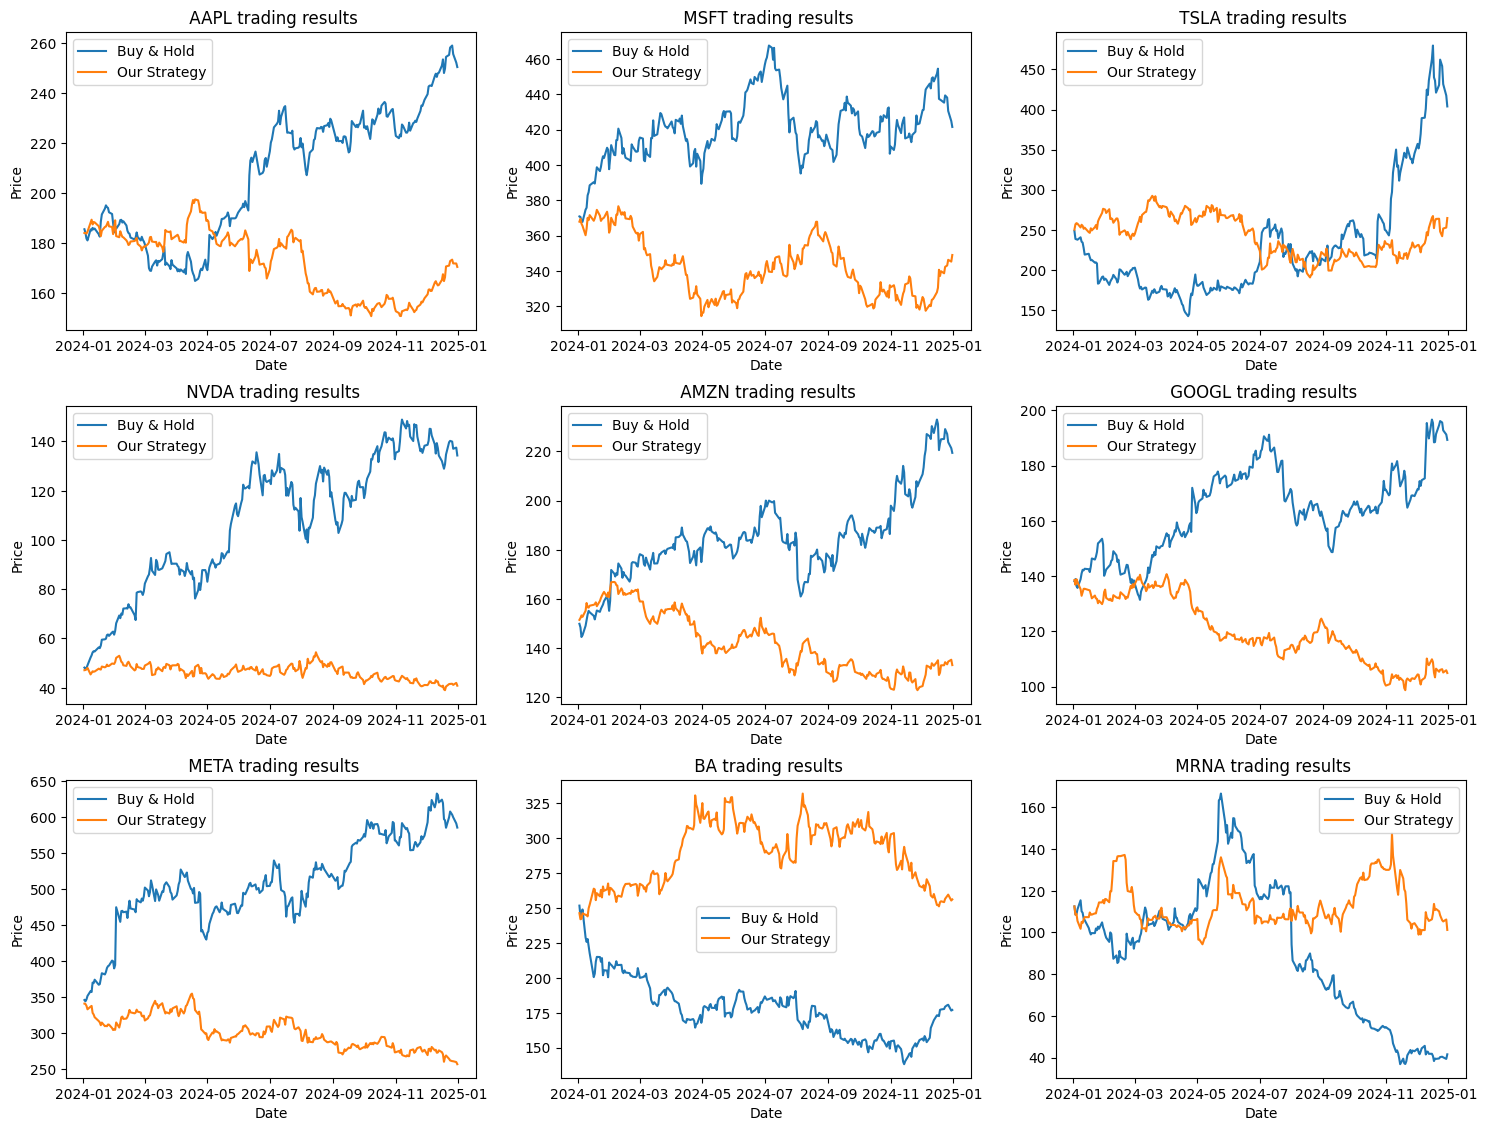

,accuracy,precision,ev,precision_ev,win B&H
第1次,0.498884,0.508757,-0.000267,-0.000358,0.22
總和,0.498884,0.508757,-0.000267,-0.000358,0.22


In [5]:
from factor import Factor

avgs = pd.DataFrame()
all_plots = []

def runAll(i, avgs):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = Factor(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1

        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
            
    # Assuming stock_results and index are defined
    df_stock_results = pd.DataFrame(stock_results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']
    df_selected = df_stock_results.loc[:, selected_columns]
    display(df_selected)

    # Create a DataFrame for the average row
    average_row = pd.DataFrame(index=['第' + str(i) + '次'])
    average_row['tp'] = [df_selected['tp'].sum()]
    average_row['fp'] = [df_selected['fp'].sum()]
    average_row['tn'] = [df_selected['tn'].sum()]
    average_row['fn'] = [df_selected['fn'].sum()]
    average_row['accuracy'] = (average_row['tp'] + average_row['tn']) / (average_row['tp'] + average_row['tn'] + average_row['fp'] + average_row['fn'])
    average_row['precision'] = average_row['tp'] / (average_row['tp'] + average_row['fp'])
    # EV 算法 每個ev成上avail_count 總和後再除上 avail_count 的平均
    average_row['avail_count'] = [df_selected['avail_count'].sum()]
    average_row['pci_avl_count'] = [df_selected['tp'].sum() + df_selected['fp'].sum()]
    average_row['ev'] = (df_selected['ev'].astype(float) * df_selected['avail_count']).sum() / df_selected['avail_count'].sum()
    average_row['precision_ev'] = (df_selected['precision_ev'].astype(float) * (df_selected['tp'] + df_selected['fp'])).sum() / (df_selected['tp'].sum() + df_selected['fp'].sum())
    average_row['win B&H'] = round(wincount / ttl_count, 2)
    avgs = pd.concat([avgs, average_row])

    df_selected_with_avg = pd.concat([df_selected, average_row])
    df_selected_with_avg['accuracy'] = df_selected_with_avg['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected_with_avg['precision'] = df_selected_with_avg['precision'].apply(lambda x: f"{x * 100:.2f}%")
    # display(df_selected_with_avg)
    return avgs

for i in range(1):
    print(i+1)
    avgs = runAll(i+1, avgs)

display_all_plots(all_plots)
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-0-1 Stock Factor OverNight

1
MSFT Microsoft us 2024Q3
1 Focus on AI Advancements: News on AI-driven improvements like video meetings and vRAN servers.
3 AI Monetization Potential: Emphasis on Azure and Copilot monetization opportunities.
4 Data Center Investments: Significant investment approvals in Ohio and Sweden.
5 Positive Comparisons: Microsoft regaining 'most valuable' company status from Nvidia.
6 Strategic Partnerships: Deals with companies like Hitachi, Ergo, and CCL for AI and cloud projects.
10 Investor Confidence: Insider reports suggesting stability and growth.
13 AI Research Progress: Advancements in responsible AI and foundational atmospheric models.
14 Stock Split Speculation: Predictions of future stock splits, aligning with Nvidia.
18 Negative Analyst Reports: Doubts over high valuations or over-reliance on AI.
19 Legal Troubles: Lawsuits from organizations like the Center for Investigative Reporting.
20 Competitor Gains: Nvidia overtaking Microsoft in market capitalization temporarily.
22 Prod

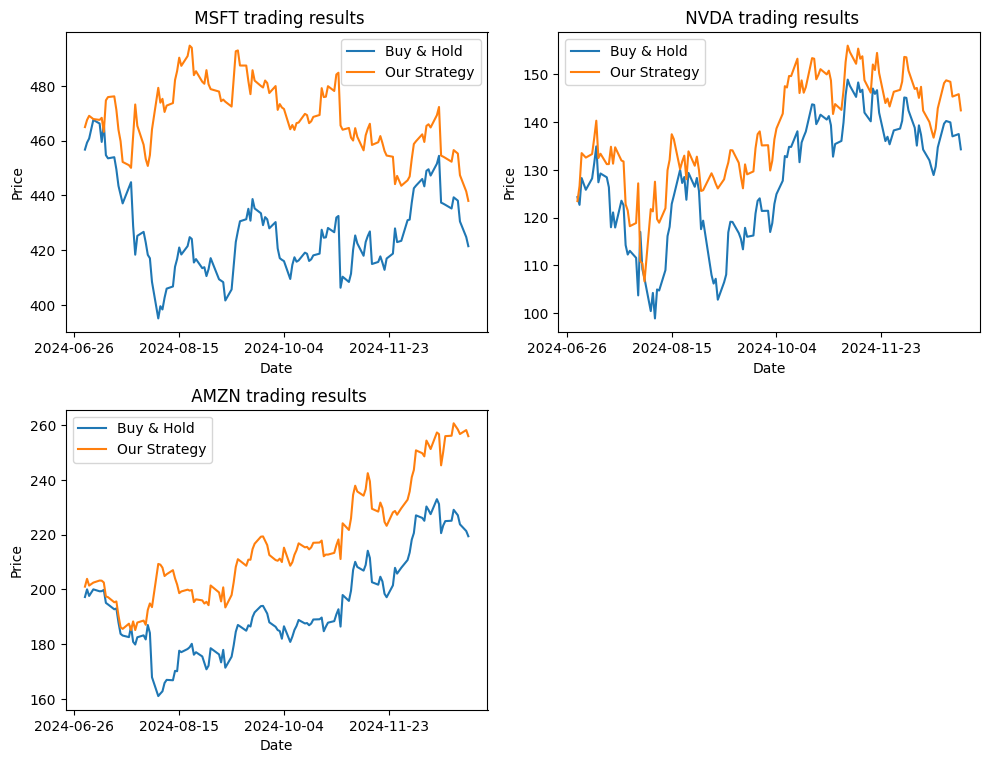

,accuracy,precision,ev,precision_ev,win B&H
第1次,45.57%,46.00%,0.00579,0.007408,1.0
總和,45.57%,46.00%,0.00579,0.007408,1.0


In [90]:
from factor_overnight import FactorON

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']


def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = FactorON(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            eval_module.show_individual(mode=1)
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])
            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        # plot fig
        if len(list_stag_rtn) == 0:
            continue
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
        # show stock results
        stock_avg = cacl_avg(pd.DataFrame(list_stock).loc[:, selected_columns])
        stock_avg.index = [stock[0]]
        stock_avg['win B&H'] = "yes" if list_stag_balance[-1] > list_bnh_rtn[-1] else "no"
        # display(stock_avg.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn', 'win B&H']])
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-0-1 Index - Factor OverNight

In [ ]:
from factor_overnight_index import FactorON_Index

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']


def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in market_index:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "components" : stock[3],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = FactorON_Index(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])
            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        # plot fig
        if len(list_stag_rtn) == 0:
            continue
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
        # show stock results
        stock_avg = cacl_avg(pd.DataFrame(list_stock).loc[:, selected_columns])
        stock_avg.index = [stock[0]]
        stock_avg['win B&H'] = "yes" if list_stag_balance[-1] > list_bnh_rtn[-1] else "no"
        display(stock_avg.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn', 'win B&H']])
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(2):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-1 EMBD OverNight

1
AAPL Apple Inc. us 2024Q1
AAPL Apple Inc. us 2024Q2
AAPL Apple Inc. us 2024Q3
AAPL Apple Inc. us 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
AAPL,0.434783,0.410256,-0.002795,-0.001629,69,16,23,14,16


MSFT Microsoft us 2024Q1
MSFT Microsoft us 2024Q2
MSFT Microsoft us 2024Q3
MSFT Microsoft us 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
MSFT,0.513514,0.6,0.001775,0.001353,74,21,14,17,22


TSLA Tesla us 2024Q1
TSLA Tesla us 2024Q2
TSLA Tesla us 2024Q3
TSLA Tesla us 2024Q4


...

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
META,0.438596,0.466667,-0.009971,-0.005642,57,7,8,18,24


BA Boeing us 2024Q1
BA Boeing us 2024Q2
BA Boeing us 2024Q3
BA Boeing us 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
BA,0.558824,0.333333,0.002244,-0.000737,34,2,4,17,11


MRNA Moderna us 2024Q1
MRNA Moderna us 2024Q2
MRNA Moderna us 2024Q3
MRNA Moderna us 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
MRNA,0.436364,0.333333,0.000334,-0.007991,55,11,22,13,9


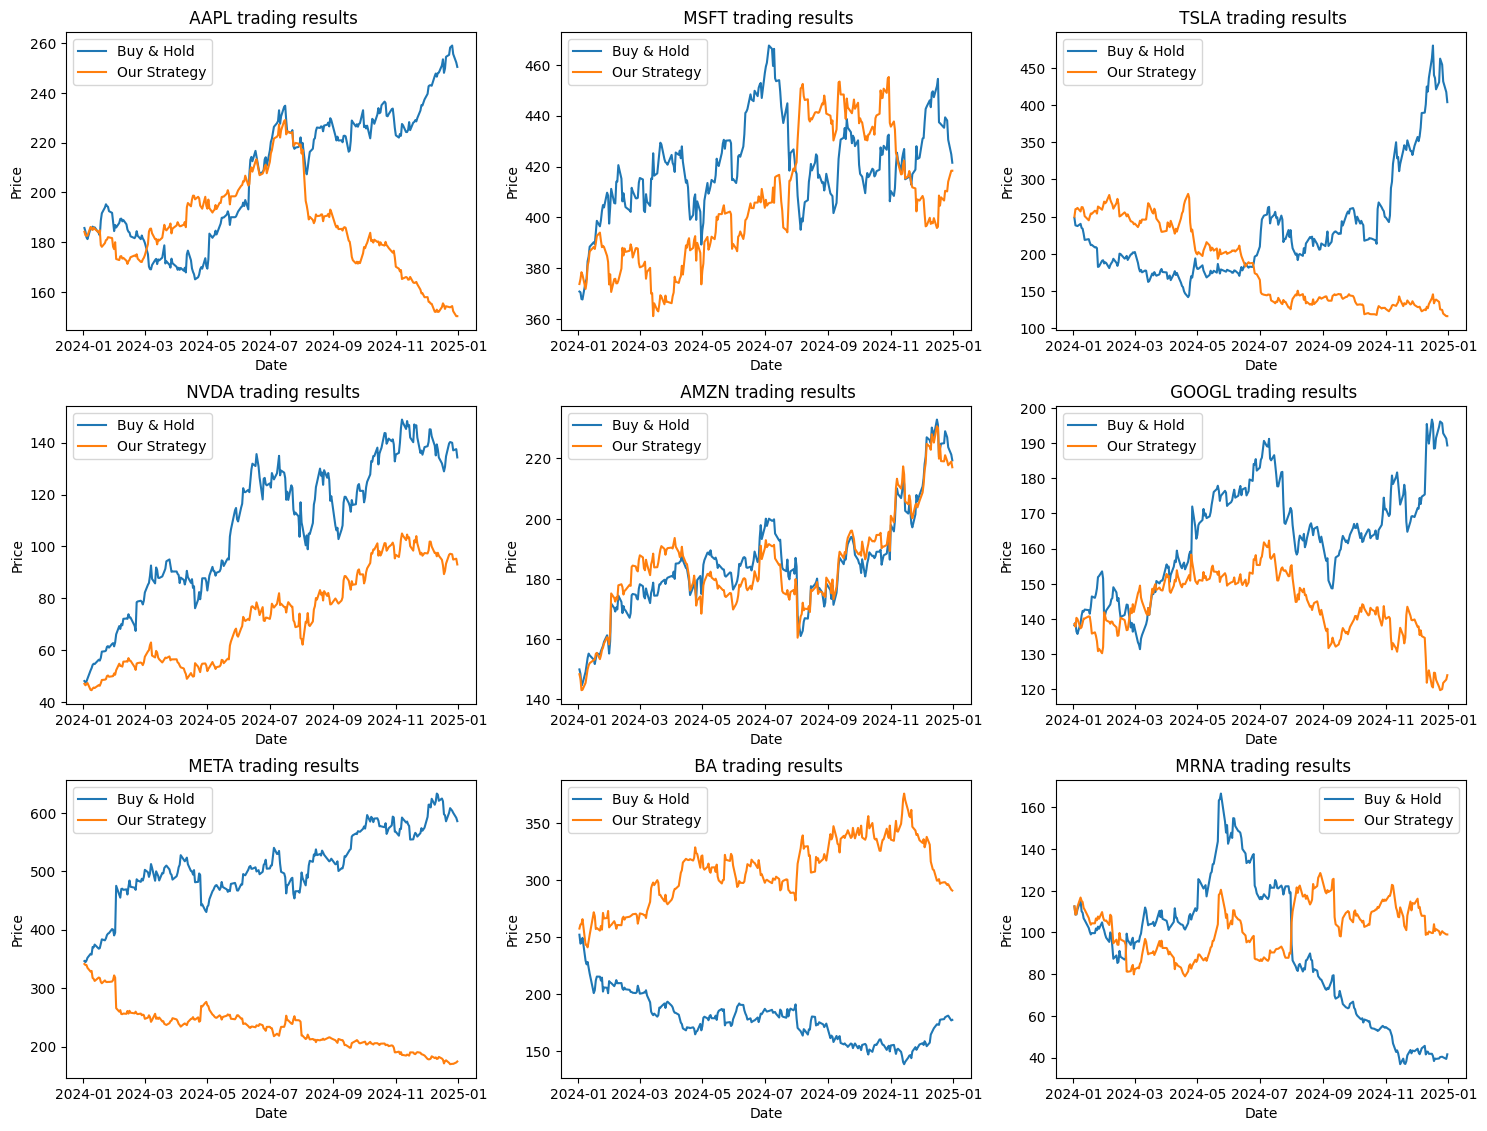

,accuracy,precision,ev,precision_ev,win B&H
第1次,48.13%,50.00%,0.000061,0.003906,0.22
總和,48.13%,50.00%,0.000061,0.003906,0.22


In [21]:
from embed import FactorEmbdON

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = FactorEmbdON(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            mode = 1    # 0:acc 1:ev
            df = eval_module.training(mode, train_datarange, test_datarange)
            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])
            
            # plot fig
            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
        
        # show stock results
        stock_avg = cacl_avg(pd.DataFrame(list_stock).loc[:, selected_columns])
        stock_avg.index = [stock[0]]
        display(stock_avg.loc[:, selected_columns])
        
        # plot fig
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-2 Index - Factor Usable DayTrade

1
twii 台灣指數期貨 tw 2022Q1
twii 台灣指數期貨 tw 2022Q2
twii 台灣指數期貨 tw 2022Q3
twii 台灣指數期貨 tw 2022Q4
twii 台灣指數期貨 tw 2023Q1
twii 台灣指數期貨 tw 2023Q2
twii 台灣指數期貨 tw 2023Q3
twii 台灣指數期貨 tw 2023Q4
twii 台灣指數期貨 tw 2024Q1
twii 台灣指數期貨 tw 2024Q2
twii 台灣指數期貨 tw 2024Q3
twii 台灣指數期貨 tw 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
0,0.543860,0.600000,0.000613,0.000156,57,18,12,13,14,NaN
1,0.564516,0.333333,0.001353,-0.002299,62,4,8,31,19,NaN
2,0.507692,0.500000,0.000186,-0.000601,65,25,25,8,7,NaN
3,0.468750,0.525000,0.000363,0.000566,64,21,19,9,15,NaN
4,0.690909,0.800000,0.001552,0.002733,55,20,5,18,12,NaN
5,0.516667,0.589744,0.000111,0.000377,60,23,16,8,13,NaN
6,0.571429,0.568627,0.000648,0.000039,63,29,22,7,5,NaN
7,0.587302,0.743590,0.001085,0.001798,63,29,10,8,16,NaN
8,0.625000,0.609756,0.002379,0.002171,56,25,16,10,5,NaN
9,0.639344,0.640000,0.002903,0.002362,61,32,18,7,4,NaN


spx S&P 500 us 2022Q1
spx S&P 500 us 2022Q2
spx S&P 500 us 2022Q3
spx S&P 500 us 2022Q4
spx S&P 500 us 2023Q1
spx S&P 500 us 2023Q2
spx S&P 500 us 2023Q3
spx S&P 500 us 2023Q4
spx S&P 500 us 2024Q1
spx S&P 500 us 2024Q2
spx S&P 500 us 2024Q3
spx S&P 500 us 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
0,0.515625,0.491803,0.000296,-0.000160,64,30,31,3,0,NaN
1,0.409836,0.415094,-0.002251,-0.002263,61,22,31,3,5,NaN
2,0.484375,0.500000,-0.000300,-0.000112,64,30,30,1,3,NaN
3,0.448276,0.460000,-0.000916,-0.000289,58,23,27,3,5,NaN
4,0.566667,0.578947,0.000846,0.001332,60,33,24,1,2,NaN
5,0.532258,0.524590,0.001397,0.001415,62,32,29,1,0,NaN
6,0.483333,0.508772,-0.001502,-0.001274,60,29,28,0,3,NaN
7,0.629032,0.661017,0.001094,0.001345,62,39,20,0,3,NaN
8,0.533333,0.545455,0.001117,0.001528,60,24,20,8,8,NaN
9,0.555556,0.550000,-0.000339,-0.000296,63,33,27,2,1,NaN


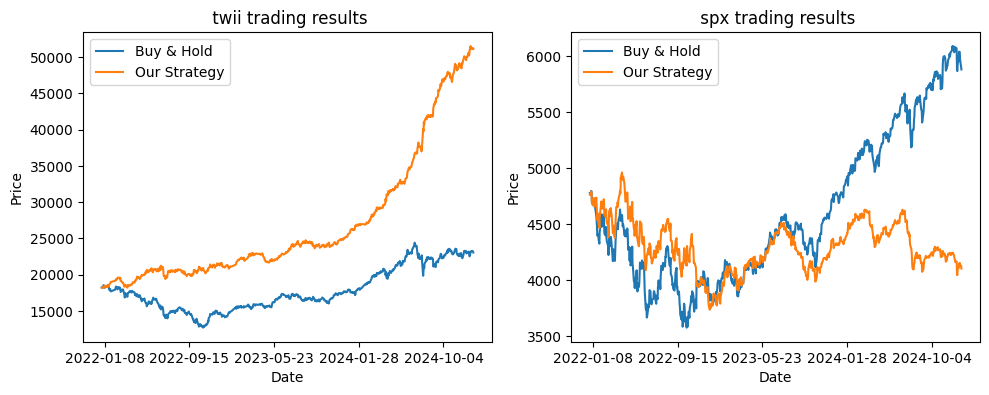

,accuracy,precision,ev,precision_ev,win B&H
第1次,54.55%,55.39%,0.000639,0.000461,0.5
總和,54.55%,55.39%,0.000639,0.000461,0.5


In [31]:
from usable_index import Index_UsableFactor

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in market_index:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "components" : stock[3],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = Index_UsableFactor(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        # plot fig
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
        # show stock results
        df_stock = pd.DataFrame(list_stock).loc[:, selected_columns]
        stock_avg = cacl_avg(df_stock)
        stock_avg.index = [stock[0]]
        stock_avg['win B&H'] = "yes" if list_stag_balance[-1] > list_bnh_rtn[-1] else "no"
        stock_avg = pd.concat([df_stock, stock_avg])
        display(stock_avg.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn', 'win B&H']])
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-2 Index - Factor Usable 

1
twii 台灣指數期貨 tw 2022Q1
twii 台灣指數期貨 tw 2022Q2
twii 台灣指數期貨 tw 2022Q3
twii 台灣指數期貨 tw 2022Q4
twii 台灣指數期貨 tw 2023Q1
twii 台灣指數期貨 tw 2023Q2
twii 台灣指數期貨 tw 2023Q3
twii 台灣指數期貨 tw 2023Q4
twii 台灣指數期貨 tw 2024Q1
twii 台灣指數期貨 tw 2024Q2
twii 台灣指數期貨 tw 2024Q3
twii 台灣指數期貨 tw 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
0,0.250000,0.250000,-0.004748,-0.004748,4,1,3,0,0,NaN
1,0.428571,0.400000,-0.009220,-0.011849,14,4,6,2,2,NaN
2,0.500000,0.555556,0.004669,0.003127,20,5,4,5,6,NaN
3,0.555556,0.666667,-0.001238,0.010366,9,2,1,3,3,NaN
4,0.416667,0.750000,-0.005198,0.005141,12,3,1,2,6,NaN
5,0.500000,0.500000,0.005537,0.013033,8,2,2,2,2,NaN
6,0.583333,0.600000,0.000492,0.001054,12,6,4,1,1,NaN
7,0.600000,0.833333,0.007869,0.014375,10,5,1,1,3,NaN
8,0.555556,0.666667,0.013871,0.020735,9,4,2,1,2,NaN
9,0.818182,1.000000,0.017708,0.000000,11,7,0,2,2,NaN


spx S&P 500 us 2022Q1
spx S&P 500 us 2022Q2
spx S&P 500 us 2022Q3
spx S&P 500 us 2022Q4
spx S&P 500 us 2023Q1
spx S&P 500 us 2023Q2
spx S&P 500 us 2023Q3
spx S&P 500 us 2023Q4
spx S&P 500 us 2024Q1
spx S&P 500 us 2024Q2
spx S&P 500 us 2024Q3
spx S&P 500 us 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
0,0.000000,0.000000,0.000000,0.000000,2,0,2,0,0,NaN
1,0.444444,0.333333,-0.022341,-0.035940,9,2,4,2,1,NaN
2,0.333333,0.500000,-0.013939,-0.019374,3,1,1,0,1,NaN
3,0.555556,0.500000,0.001873,0.001909,9,4,4,1,0,NaN
4,0.666667,0.666667,0.028526,0.028526,3,2,1,0,0,NaN
5,1.000000,1.000000,0.000000,0.000000,1,1,0,0,0,NaN
6,0.000000,0.000000,0.000000,0.000000,3,0,3,0,0,NaN
7,1.000000,1.000000,0.000000,0.000000,2,2,0,0,0,NaN
8,0.727273,0.727273,0.009670,0.009670,11,8,3,0,0,NaN
9,0.500000,0.500000,0.010977,0.010977,4,2,2,0,0,NaN


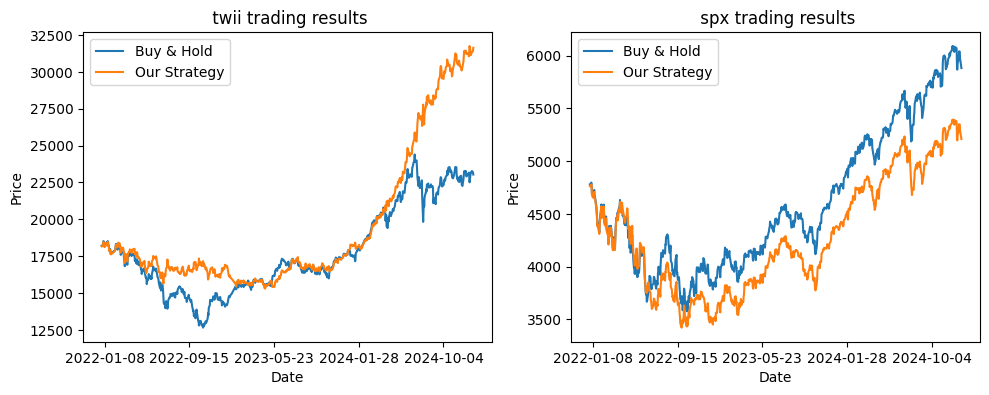

,accuracy,precision,ev,precision_ev,win B&H
第1次,54.21%,57.81%,0.003332,0.003386,0.5
總和,54.21%,57.81%,0.003332,0.003386,0.5


In [36]:
from usable_on_index import Index_UsableFactorON

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in market_index:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "components" : stock[3],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = Index_UsableFactorON(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']])
            # eval_module.show_individual(mode=1)

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        # plot fig
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
        # show stock results
        df_stock = pd.DataFrame(list_stock).loc[:, selected_columns]
        stock_avg = cacl_avg(df_stock)
        stock_avg.index = [stock[0]]
        stock_avg['win B&H'] = "yes" if list_stag_balance[-1] > list_bnh_rtn[-1] else "no"
        stock_avg = pd.concat([df_stock, stock_avg])
        display(stock_avg.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn', 'win B&H']])
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-2 Stock - Factor Usable

1
AAPL Apple Inc. us 2024Q3
AAPL Apple Inc. us 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
AAPL,0.411765,0.52,-0.004611,-0.00058,34,13,12,1,8,no


MSFT Microsoft us 2024Q3
MSFT Microsoft us 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
MSFT,0.448276,0.5,0.002142,0.001561,29,8,8,5,8,yes


NVDA Nvidia us 2024Q3
NVDA Nvidia us 2024Q4


...

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
META,0.354839,0.409091,0.001455,0.005261,31,9,13,2,7,no


GOOGL Google us 2024Q3
GOOGL Google us 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
GOOGL,0.518519,0.5,-0.001416,-0.004691,27,8,8,6,5,no


TSLA Tesla us 2024Q3
TSLA Tesla us 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
TSLA,0.382353,0.5,0.003807,0.01911,34,9,9,4,12,no


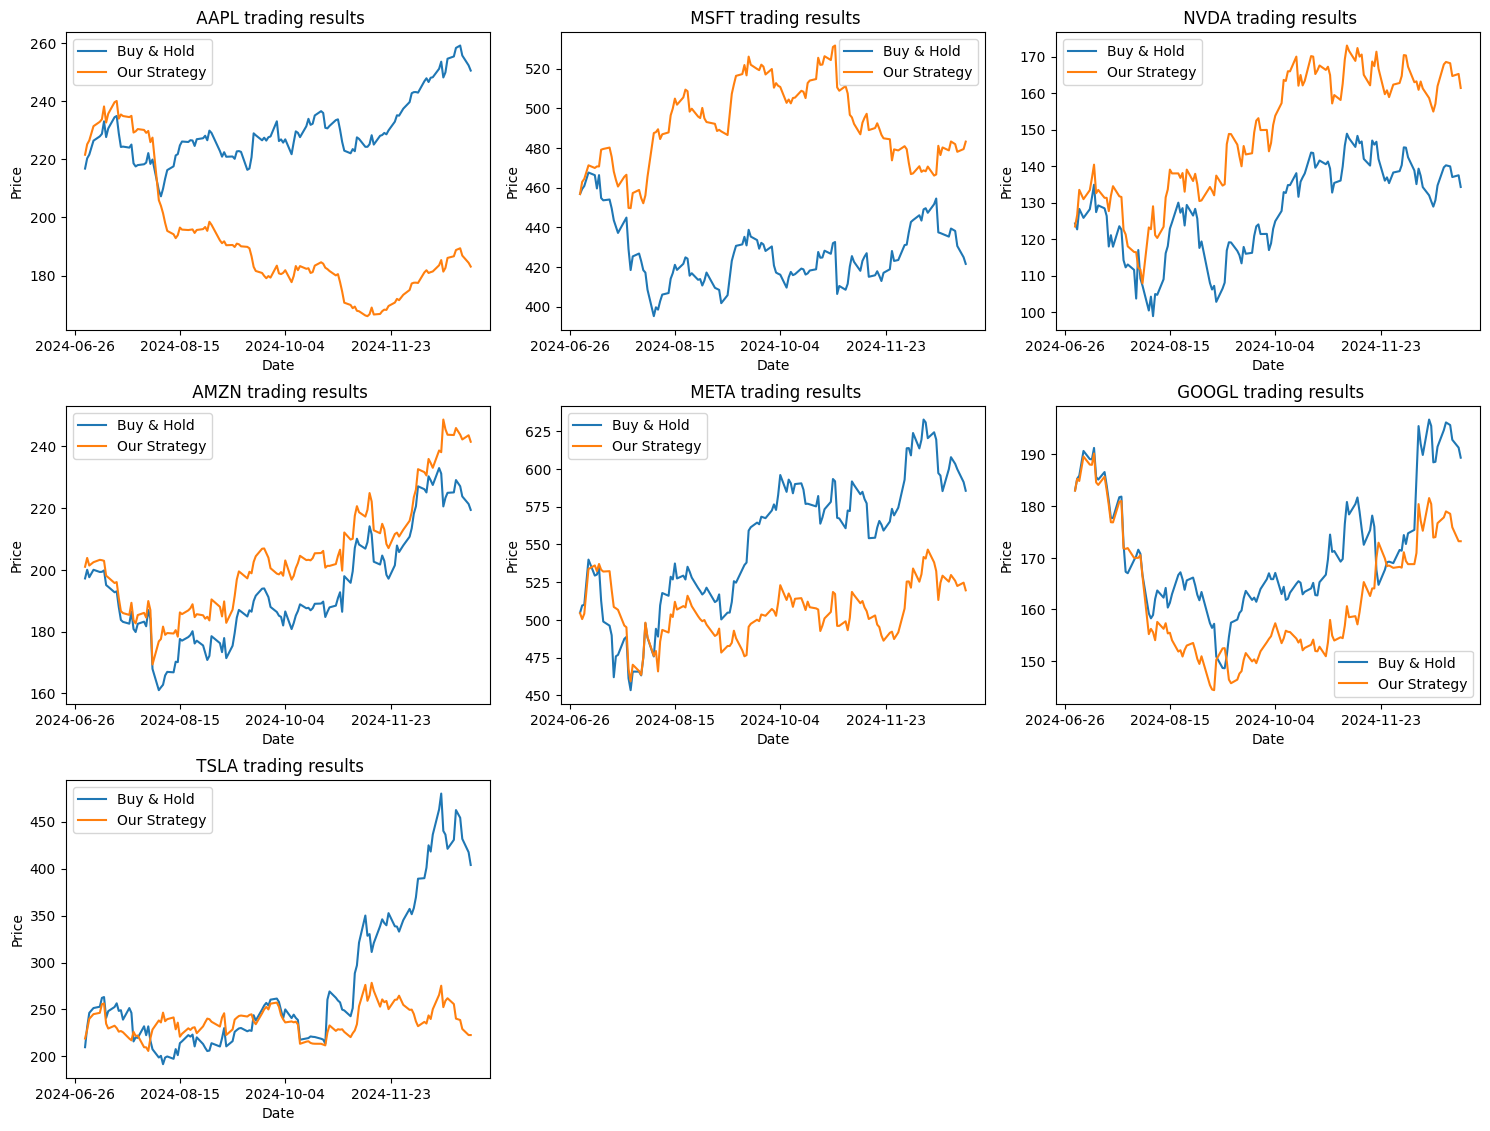

,accuracy,precision,ev,precision_ev,win B&H
第1次,46.19%,51.18%,0.003001,0.006373,0.43
總和,46.19%,51.18%,0.003001,0.006373,0.43


In [ ]:
## V1
from usable_on import UsableFactorON

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = UsableFactorON(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        # plot fig
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
        # show stock results
        stock_avg = cacl_avg(pd.DataFrame(list_stock).loc[:, selected_columns])
        stock_avg.index = [stock[0]]
        stock_avg['win B&H'] = "yes" if list_stag_balance[-1] > list_bnh_rtn[-1] else "no"
        display(stock_avg.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn', 'win B&H']])
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-2-1 Index Factor Usable + eval only long

1
twii 台灣指數期貨 tw 2022Q1
twii 台灣指數期貨 tw 2022Q2
twii 台灣指數期貨 tw 2022Q3
twii 台灣指數期貨 tw 2022Q4
twii 台灣指數期貨 tw 2023Q1
twii 台灣指數期貨 tw 2023Q2
twii 台灣指數期貨 tw 2023Q3
twii 台灣指數期貨 tw 2023Q4
twii 台灣指數期貨 tw 2024Q1
twii 台灣指數期貨 tw 2024Q2
twii 台灣指數期貨 tw 2024Q3
twii 台灣指數期貨 tw 2024Q4


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
0,0.250000,0.250000,-0.004748,-0.004748,4,1,3,0,0,NaN
1,0.333333,0.333333,-0.019763,-0.019763,9,3,6,0,0,NaN
2,0.500000,0.500000,-0.000443,-0.000443,12,6,6,0,0,NaN
3,0.400000,0.400000,0.003267,0.003267,15,6,9,0,0,NaN
4,0.727273,0.727273,0.005186,0.005186,11,8,3,0,0,NaN
5,0.750000,0.750000,0.014167,0.014167,4,3,1,0,0,NaN
6,0.800000,0.800000,0.000465,0.000465,5,4,1,0,0,NaN
7,0.666667,0.666667,0.009185,0.009185,9,6,3,0,0,NaN
8,0.666667,0.666667,0.023038,0.023038,6,4,2,0,0,NaN
9,0.875000,0.875000,0.024009,0.024009,8,7,1,0,0,NaN


spx S&P 500 us 2022Q1
Start Running Genetic Algorithm
spx S&P 500 us 2022Q2
Start Running Genetic Algorithm
spx S&P 500 us 2022Q3
Start Running Genetic Algorithm
spx S&P 500 us 2022Q4
Start Running Genetic Algorithm
spx S&P 500 us 2023Q1
Start Running Genetic Algorithm
spx S&P 500 us 2023Q2
Start Running Genetic Algorithm
spx S&P 500 us 2023Q3
Start Running Genetic Algorithm
spx S&P 500 us 2023Q4
Start Running Genetic Algorithm
spx S&P 500 us 2024Q1
Start Running Genetic Algorithm
spx S&P 500 us 2024Q2
Start Running Genetic Algorithm
spx S&P 500 us 2024Q3
Start Running Genetic Algorithm
spx S&P 500 us 2024Q4
Start Running Genetic Algorithm


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
0,0.500000,0.500000,-0.034525,-0.034525,2,1,1,0,0,NaN
1,0.166667,0.166667,-0.036787,-0.036787,6,1,5,0,0,NaN
2,0.666667,0.666667,-0.007352,-0.007352,6,4,2,0,0,NaN
3,0.500000,0.500000,0.003416,0.003416,8,4,4,0,0,NaN
4,0.750000,0.750000,0.022494,0.022494,4,3,1,0,0,NaN
5,1.000000,1.000000,0.000000,0.000000,2,2,0,0,0,NaN
6,0.000000,0.000000,0.000000,0.000000,3,0,3,0,0,NaN
7,0.666667,0.666667,0.016860,0.016860,6,4,2,0,0,NaN
8,0.750000,0.750000,0.013448,0.013448,8,6,2,0,0,NaN
9,0.500000,0.500000,0.010977,0.010977,4,2,2,0,0,NaN


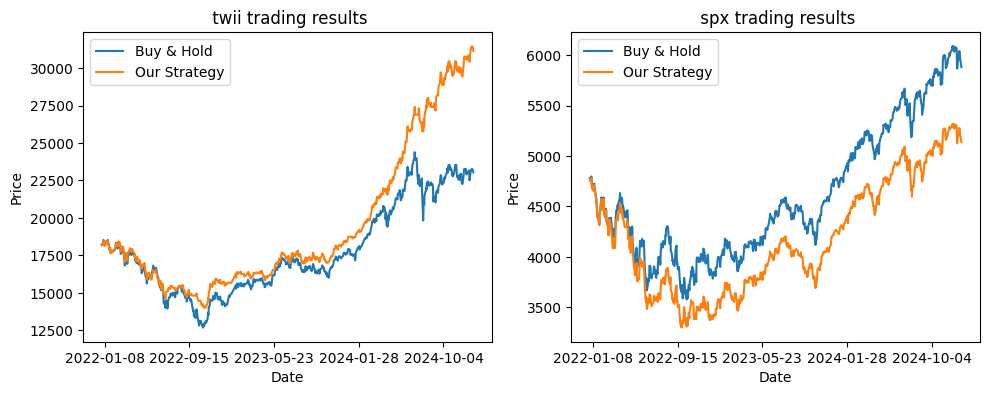

,accuracy,precision,ev,precision_ev,win B&H
第1次,56.41%,56.41%,0.004184,0.004184,0.5
總和,56.41%,56.41%,0.004184,0.004184,0.5


In [32]:
from usable_on_long_index import Index_UsableFactorONLong

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in market_index:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "components" : stock[3],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = Index_UsableFactorONLong(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        # plot fig
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
        # show stock results
        df_stock = pd.DataFrame(list_stock).loc[:, selected_columns]
        stock_avg = cacl_avg(df_stock)
        stock_avg.index = [stock[0]]
        stock_avg['win B&H'] = "yes" if list_stag_balance[-1] > list_bnh_rtn[-1] else "no"
        stock_avg = pd.concat([df_stock, stock_avg])
        display(stock_avg.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn', 'win B&H']])
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-2-1 Stock Factor Usable + eval only long

1
AAPL Apple Inc. us 2024Q1
AAPL Apple Inc. us 2024Q2
AAPL Apple Inc. us 2024Q3
AAPL Apple Inc. us 2024Q4
MSFT Microsoft us 2024Q1
MSFT Microsoft us 2024Q2
MSFT Microsoft us 2024Q3
MSFT Microsoft us 2024Q4
NVDA Nvidia us 2024Q1
NVDA Nvidia us 2024Q2
NVDA Nvidia us 2024Q3
NVDA Nvidia us 2024Q4
AMZN Amazon inc. us 2024Q1
AMZN Amazon inc. us 2024Q2
AMZN Amazon inc. us 2024Q3
AMZN Amazon inc. us 2024Q4
META Meta Platforms us 2024Q1
META Meta Platforms us 2024Q2
META Meta Platforms us 2024Q3
META Meta Platforms us 2024Q4
GOOGL Google us 2024Q1
GOOGL Google us 2024Q2
GOOGL Google us 2024Q3
GOOGL Google us 2024Q4
TSLA Tesla us 2024Q1
TSLA Tesla us 2024Q2
TSLA Tesla us 2024Q3
TSLA Tesla us 2024Q4


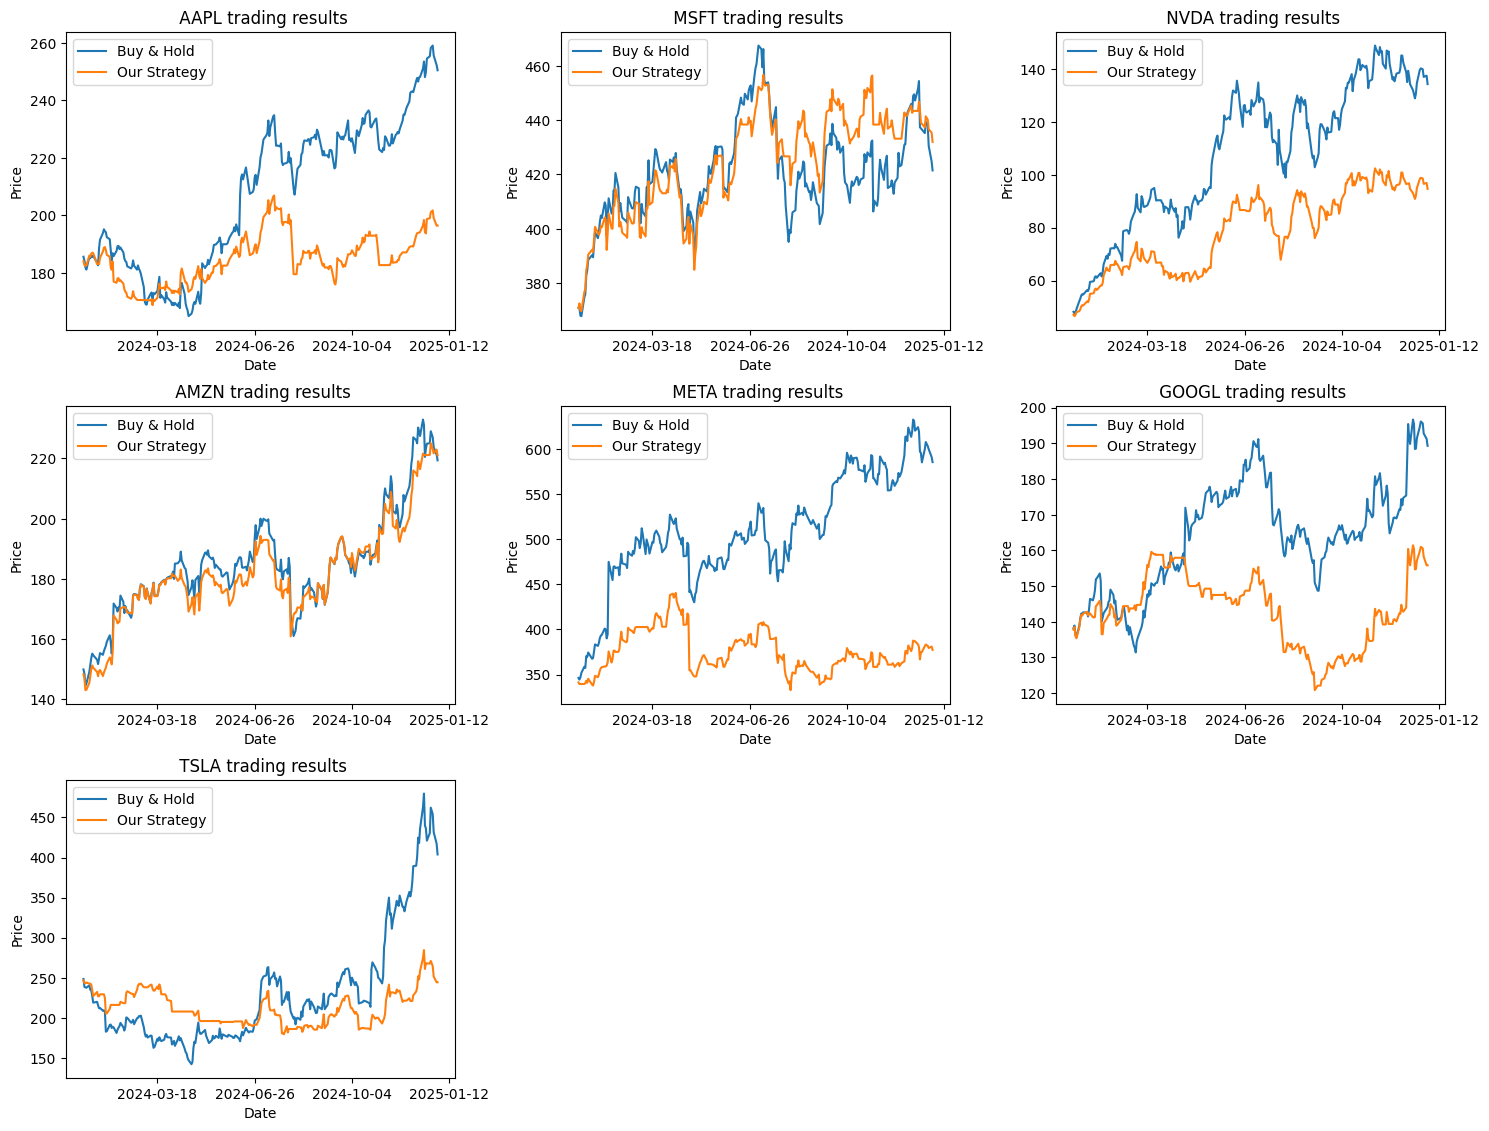

,accuracy,precision,ev,precision_ev,win B&H
第1次,0.522807,0.522807,0.006513,0.006513,0.29
總和,0.522807,0.522807,0.006513,0.006513,0.29


In [17]:
from usable_on_long import UsableFactorONLong

avgs = pd.DataFrame()
all_plots = []

def runAll(i, avgs):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = UsableFactorONLong(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            # print(stock_results)

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1

        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
            
    # Assuming stock_results and index are defined
    df_stock_results = pd.DataFrame(stock_results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']
    df_selected = df_stock_results.loc[:, selected_columns]
    # display(df_selected)

    # Create a DataFrame for the average row
    average_row = pd.DataFrame(index=['第' + str(i) + '次'])
    average_row['tp'] = [df_selected['tp'].sum()]
    average_row['fp'] = [df_selected['fp'].sum()]
    average_row['tn'] = [df_selected['tn'].sum()]
    average_row['fn'] = [df_selected['fn'].sum()]
    average_row['accuracy'] = (average_row['tp'] + average_row['tn']) / (average_row['tp'] + average_row['tn'] + average_row['fp'] + average_row['fn'])
    average_row['precision'] = average_row['tp'] / (average_row['tp'] + average_row['fp'])
    # EV 算法 每個ev成上avail_count 總和後再除上 avail_count 的平均
    average_row['avail_count'] = [df_selected['avail_count'].sum()]
    average_row['pci_avl_count'] = [df_selected['tp'].sum() + df_selected['fp'].sum()]
    average_row['ev'] = (df_selected['ev'].astype(float) * df_selected['avail_count']).sum() / df_selected['avail_count'].sum()
    average_row['precision_ev'] = (df_selected['precision_ev'].astype(float) * (df_selected['tp'] + df_selected['fp'])).sum() / (df_selected['tp'].sum() + df_selected['fp'].sum())
    average_row['win B&H'] = round(wincount / ttl_count, 2)
    avgs = pd.concat([avgs, average_row])

    df_selected_with_avg = pd.concat([df_selected, average_row])
    df_selected_with_avg['accuracy'] = df_selected_with_avg['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected_with_avg['precision'] = df_selected_with_avg['precision'].apply(lambda x: f"{x * 100:.2f}%")
    # display(df_selected_with_avg)
    return avgs

for i in range(1):
    print(i+1)
    avgs = runAll(i+1, avgs)

display_all_plots(all_plots)
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-2-2 Factor Usable + eval only short

1
AAPL Apple Inc. us 2024Q1
Start Running Genetic Algorithm
AAPL Apple Inc. us 2024Q2
Start Running Genetic Algorithm
AAPL Apple Inc. us 2024Q3
Start Running Genetic Algorithm
AAPL Apple Inc. us 2024Q4
Start Running Genetic Algorithm
MSFT Microsoft us 2024Q1
Start Running Genetic Algorithm
MSFT Microsoft us 2024Q2
Start Running Genetic Algorithm
MSFT Microsoft us 2024Q3
Start Running Genetic Algorithm
MSFT Microsoft us 2024Q4
Start Running Genetic Algorithm
TSLA Tesla us 2024Q1
Start Running Genetic Algorithm
TSLA Tesla us 2024Q2
Start Running Genetic Algorithm
TSLA Tesla us 2024Q3
Start Running Genetic Algorithm
TSLA Tesla us 2024Q4
Start Running Genetic Algorithm
NVDA Nvidia us 2024Q1
Start Running Genetic Algorithm
NVDA Nvidia us 2024Q2
Start Running Genetic Algorithm
NVDA Nvidia us 2024Q3
Start Running Genetic Algorithm
NVDA Nvidia us 2024Q4
Start Running Genetic Algorithm
AMZN Amazon inc. us 2024Q1
Start Running Genetic Algorithm
AMZN Amazon inc. us 2024Q2
Start Running Genetic Al

/var/folders/xc/rjj8m66j6xs5pgcp1hc7g2kr0000gn/T/ipykernel_2341/2480614451.py:79: RuntimeWarning: invalid value encountered in scalar divide
  average_row['precision_ev'] = (df_selected['precision_ev'].astype(float) * (df_selected['tp'] + df_selected['fp'])).sum() / (df_selected['tp'].sum() + df_selected['fp'].sum())


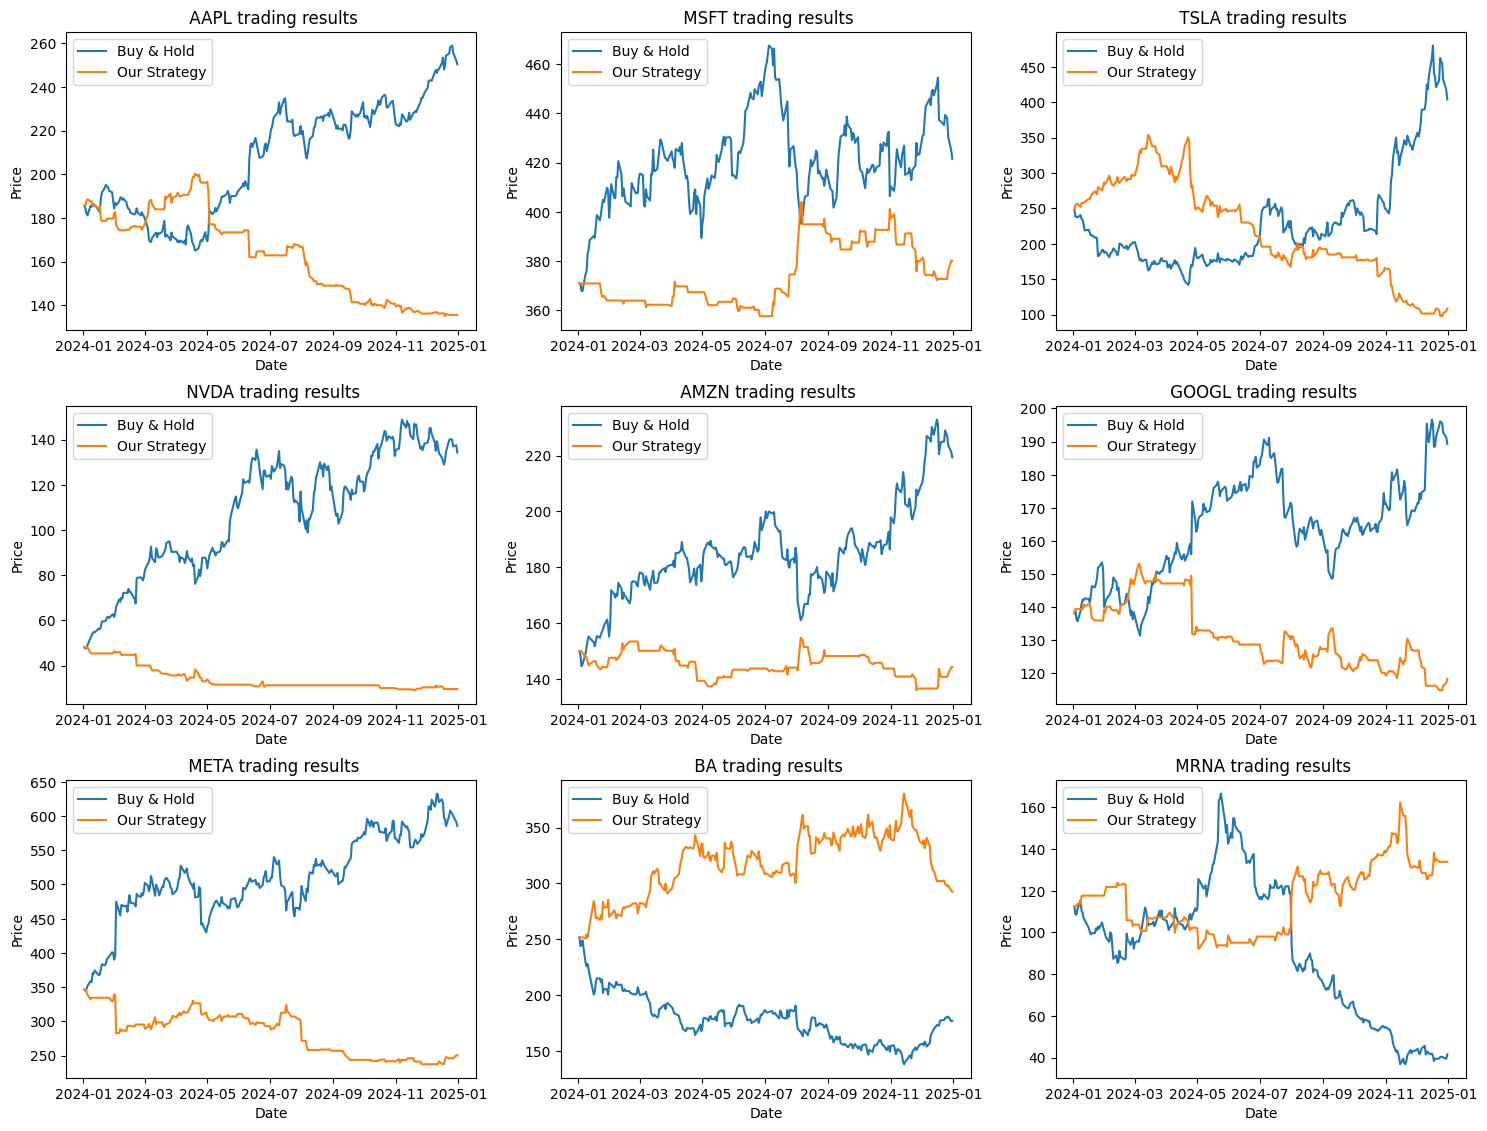

,accuracy,precision,ev,precision_ev,win B&H
第1次,0.479675,NaN,-0.004339,NaN,0.22
總和,0.479675,NaN,-0.004339,NaN,0.22


In [6]:
from usable_on_short import UsableFactorONShort

avgs = pd.DataFrame()
all_plots = []

def runAll(i, avgs):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = UsableFactorONShort(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            # print(stock_results)

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1

        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
            
    # Assuming stock_results and index are defined
    df_stock_results = pd.DataFrame(stock_results, index=index)
    selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']
    df_selected = df_stock_results.loc[:, selected_columns]
    # display(df_selected)

    # Create a DataFrame for the average row
    average_row = pd.DataFrame(index=['第' + str(i) + '次'])
    average_row['tp'] = [df_selected['tp'].sum()]
    average_row['fp'] = [df_selected['fp'].sum()]
    average_row['tn'] = [df_selected['tn'].sum()]
    average_row['fn'] = [df_selected['fn'].sum()]
    average_row['accuracy'] = (average_row['tp'] + average_row['tn']) / (average_row['tp'] + average_row['tn'] + average_row['fp'] + average_row['fn'])
    average_row['precision'] = average_row['tp'] / (average_row['tp'] + average_row['fp'])
    # EV 算法 每個ev成上avail_count 總和後再除上 avail_count 的平均
    average_row['avail_count'] = [df_selected['avail_count'].sum()]
    average_row['pci_avl_count'] = [df_selected['tp'].sum() + df_selected['fp'].sum()]
    average_row['ev'] = (df_selected['ev'].astype(float) * df_selected['avail_count']).sum() / df_selected['avail_count'].sum()
    average_row['precision_ev'] = (df_selected['precision_ev'].astype(float) * (df_selected['tp'] + df_selected['fp'])).sum() / (df_selected['tp'].sum() + df_selected['fp'].sum())
    average_row['win B&H'] = round(wincount / ttl_count, 2)
    avgs = pd.concat([avgs, average_row])

    df_selected_with_avg = pd.concat([df_selected, average_row])
    df_selected_with_avg['accuracy'] = df_selected_with_avg['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
    df_selected_with_avg['precision'] = df_selected_with_avg['precision'].apply(lambda x: f"{x * 100:.2f}%")
    # display(df_selected_with_avg)
    return avgs

for i in range(1):
    print(i+1)
    avgs = runAll(i+1, avgs)

display_all_plots(all_plots)
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-3 Factor Usable + MA

1
AAPL Apple Inc. us 2024Q1
AAPL Apple Inc. us 2024Q2
AAPL Apple Inc. us 2024Q3
AAPL Apple Inc. us 2024Q4
MSFT Microsoft us 2024Q1
MSFT Microsoft us 2024Q2
MSFT Microsoft us 2024Q3
MSFT Microsoft us 2024Q4
NVDA Nvidia us 2024Q1
NVDA Nvidia us 2024Q2
NVDA Nvidia us 2024Q3
NVDA Nvidia us 2024Q4
AMZN Amazon inc. us 2024Q1
AMZN Amazon inc. us 2024Q2
AMZN Amazon inc. us 2024Q3
AMZN Amazon inc. us 2024Q4
META Meta Platforms us 2024Q1
META Meta Platforms us 2024Q2
META Meta Platforms us 2024Q3
META Meta Platforms us 2024Q4
GOOGL Google us 2024Q1
GOOGL Google us 2024Q2
GOOGL Google us 2024Q3
GOOGL Google us 2024Q4
TSLA Tesla us 2024Q1
TSLA Tesla us 2024Q2
TSLA Tesla us 2024Q3
TSLA Tesla us 2024Q4


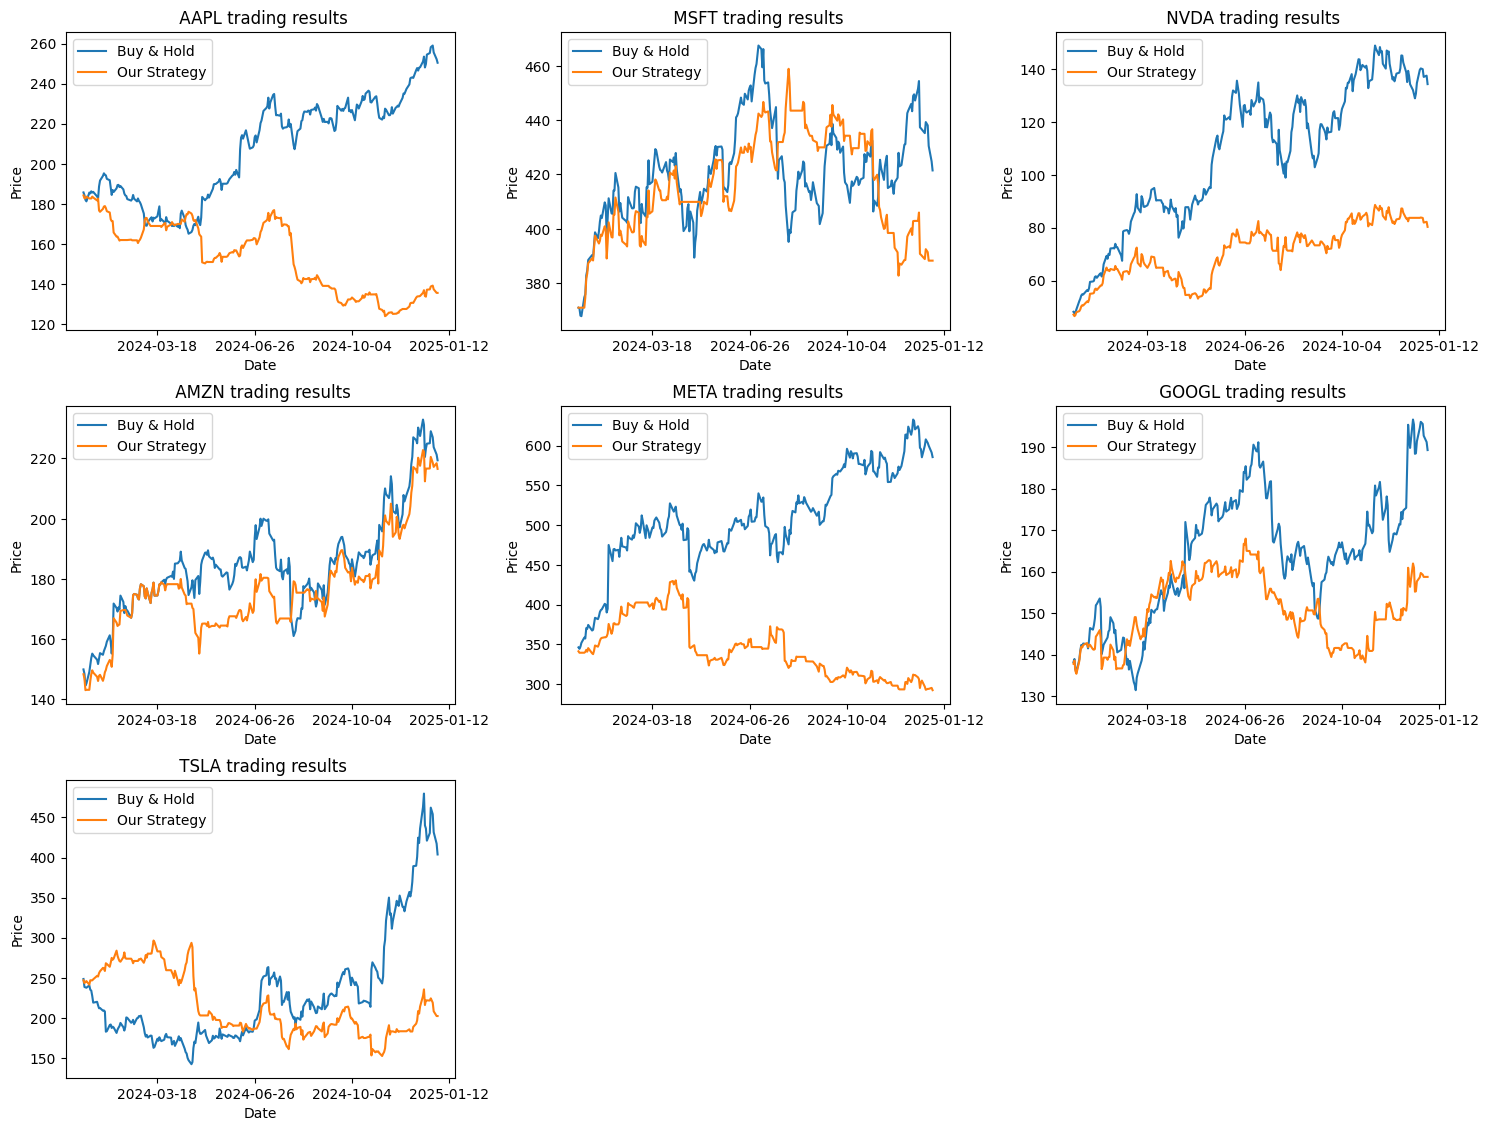

,accuracy,precision,ev,precision_ev,win B&H
第1次,48.63%,53.30%,0.002502,0.007069,0.0
總和,48.63%,53.30%,0.002502,0.007069,0.0


In [ ]:
from usable_movement import UsableMovment

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "MOV": "EMA26",
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = UsableMovment(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        # # show stock results
        # stock_avg = cacl_avg(pd.DataFrame(list_stock).loc[:, selected_columns])
        # stock_avg.index = [stock[0]]
        # display(stock_avg.loc[:, selected_columns])
        
        # plot fig
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-4 Factor Usable Reason

1
AAPL Apple Inc. us 2024Q1
AAPL Apple Inc. us 2024Q2
AAPL Apple Inc. us 2024Q3
AAPL Apple Inc. us 2024Q4
MSFT Microsoft us 2024Q1
MSFT Microsoft us 2024Q2
MSFT Microsoft us 2024Q3
MSFT Microsoft us 2024Q4
NVDA Nvidia us 2024Q1
NVDA Nvidia us 2024Q2
NVDA Nvidia us 2024Q3
NVDA Nvidia us 2024Q4
AMZN Amazon inc. us 2024Q1
AMZN Amazon inc. us 2024Q2
AMZN Amazon inc. us 2024Q3
AMZN Amazon inc. us 2024Q4
META Meta Platforms us 2024Q1
META Meta Platforms us 2024Q2
META Meta Platforms us 2024Q3
META Meta Platforms us 2024Q4
GOOGL Google us 2024Q1
GOOGL Google us 2024Q2
GOOGL Google us 2024Q3
GOOGL Google us 2024Q4
TSLA Tesla us 2024Q1
TSLA Tesla us 2024Q2
TSLA Tesla us 2024Q3
TSLA Tesla us 2024Q4


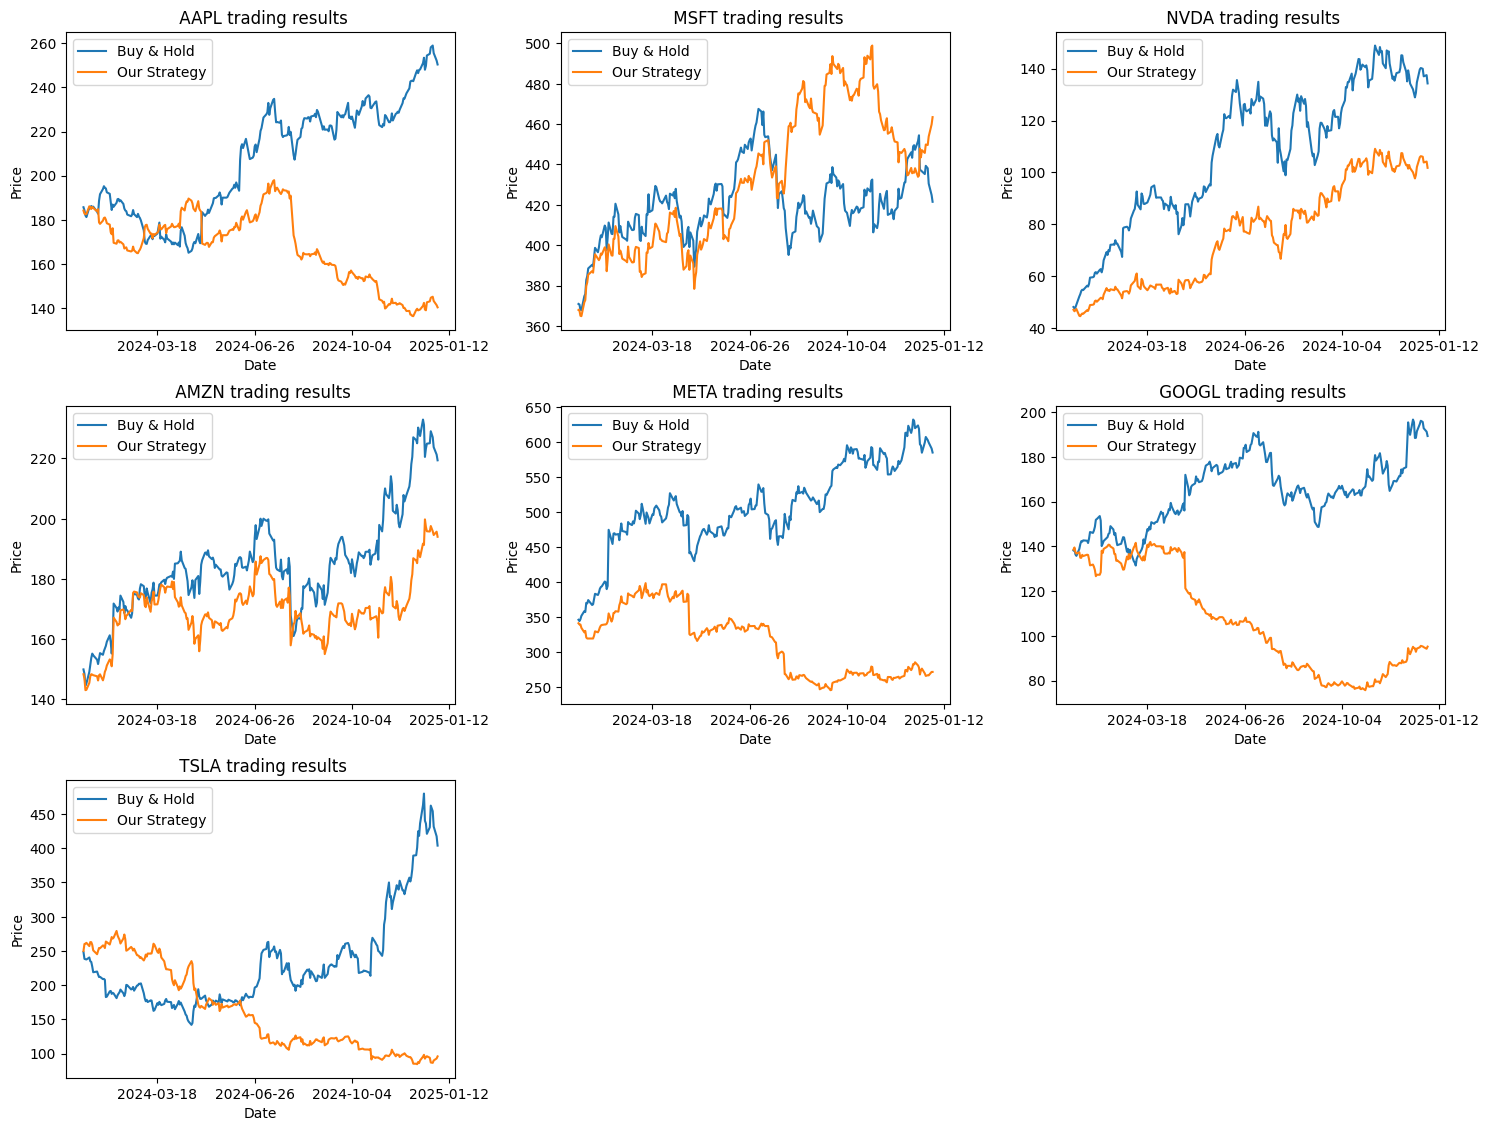

,accuracy,precision,ev,precision_ev,win B&H
第1次,48.95%,53.78%,-0.000365,0.005432,0.14
總和,48.95%,53.78%,-0.000365,0.005432,0.14


In [18]:
from usable_on_reason import UsableReasonON

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = UsableReasonON(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            mode = 1    # 0:acc 1:ev
            df = eval_module.training(mode, train_datarange, test_datarange)
            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])
            
            # plot fig
            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
        
        # # show stock results
        # stock_avg = cacl_avg(pd.DataFrame(list_stock).loc[:, selected_columns])
        # stock_avg.index = [stock[0]]
        # display(stock_avg.loc[:, selected_columns])
        
        # plot fig
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-5 Factor Usable Volatility

1


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
AAPL,0.487179,0.566667,-0.002872,0.000393,39,17,13,2,7,no


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
MSFT,0.484848,0.541667,0.004743,0.007505,33,13,11,3,6,yes


/var/folders/xc/rjj8m66j6xs5pgcp1hc7g2kr0000gn/T/ipykernel_10847/2006858619.py:16: RuntimeWarning: invalid value encountered in scalar divide
  average_row['ev'] = (df_stocks_results['ev'].astype(float) * df_stocks_results['avail_count']).sum() / df_stocks_results['avail_count'].sum()
/var/folders/xc/rjj8m66j6xs5pgcp1hc7g2kr0000gn/T/ipykernel_10847/2006858619.py:17: RuntimeWarning: invalid value encountered in scalar divide
  average_row['precision_ev'] = (df_stocks_results['precision_ev'].astype(float) * (df_stocks_results['tp'] + df_stocks_results['fp'])).sum() / (df_stocks_results['tp'].sum() + df_stocks_results['fp'].sum())


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
NVDA,NaN,NaN,NaN,NaN,0,0,0,0,0,no


...

/var/folders/xc/rjj8m66j6xs5pgcp1hc7g2kr0000gn/T/ipykernel_10847/2006858619.py:16: RuntimeWarning: invalid value encountered in scalar divide
  average_row['ev'] = (df_stocks_results['ev'].astype(float) * df_stocks_results['avail_count']).sum() / df_stocks_results['avail_count'].sum()
/var/folders/xc/rjj8m66j6xs5pgcp1hc7g2kr0000gn/T/ipykernel_10847/2006858619.py:17: RuntimeWarning: invalid value encountered in scalar divide
  average_row['precision_ev'] = (df_stocks_results['precision_ev'].astype(float) * (df_stocks_results['tp'] + df_stocks_results['fp'])).sum() / (df_stocks_results['tp'].sum() + df_stocks_results['fp'].sum())


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
MRNA,NaN,NaN,NaN,NaN,0,0,0,0,0,yes


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
WMT,0.62,0.757576,0.006691,0.013274,50,25,8,6,11,no


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
UNH,0.516129,0.666667,-0.000222,0.00141,31,10,5,6,10,yes


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
DIS,0.456522,0.56,0.00107,0.006216,46,14,11,7,14,no


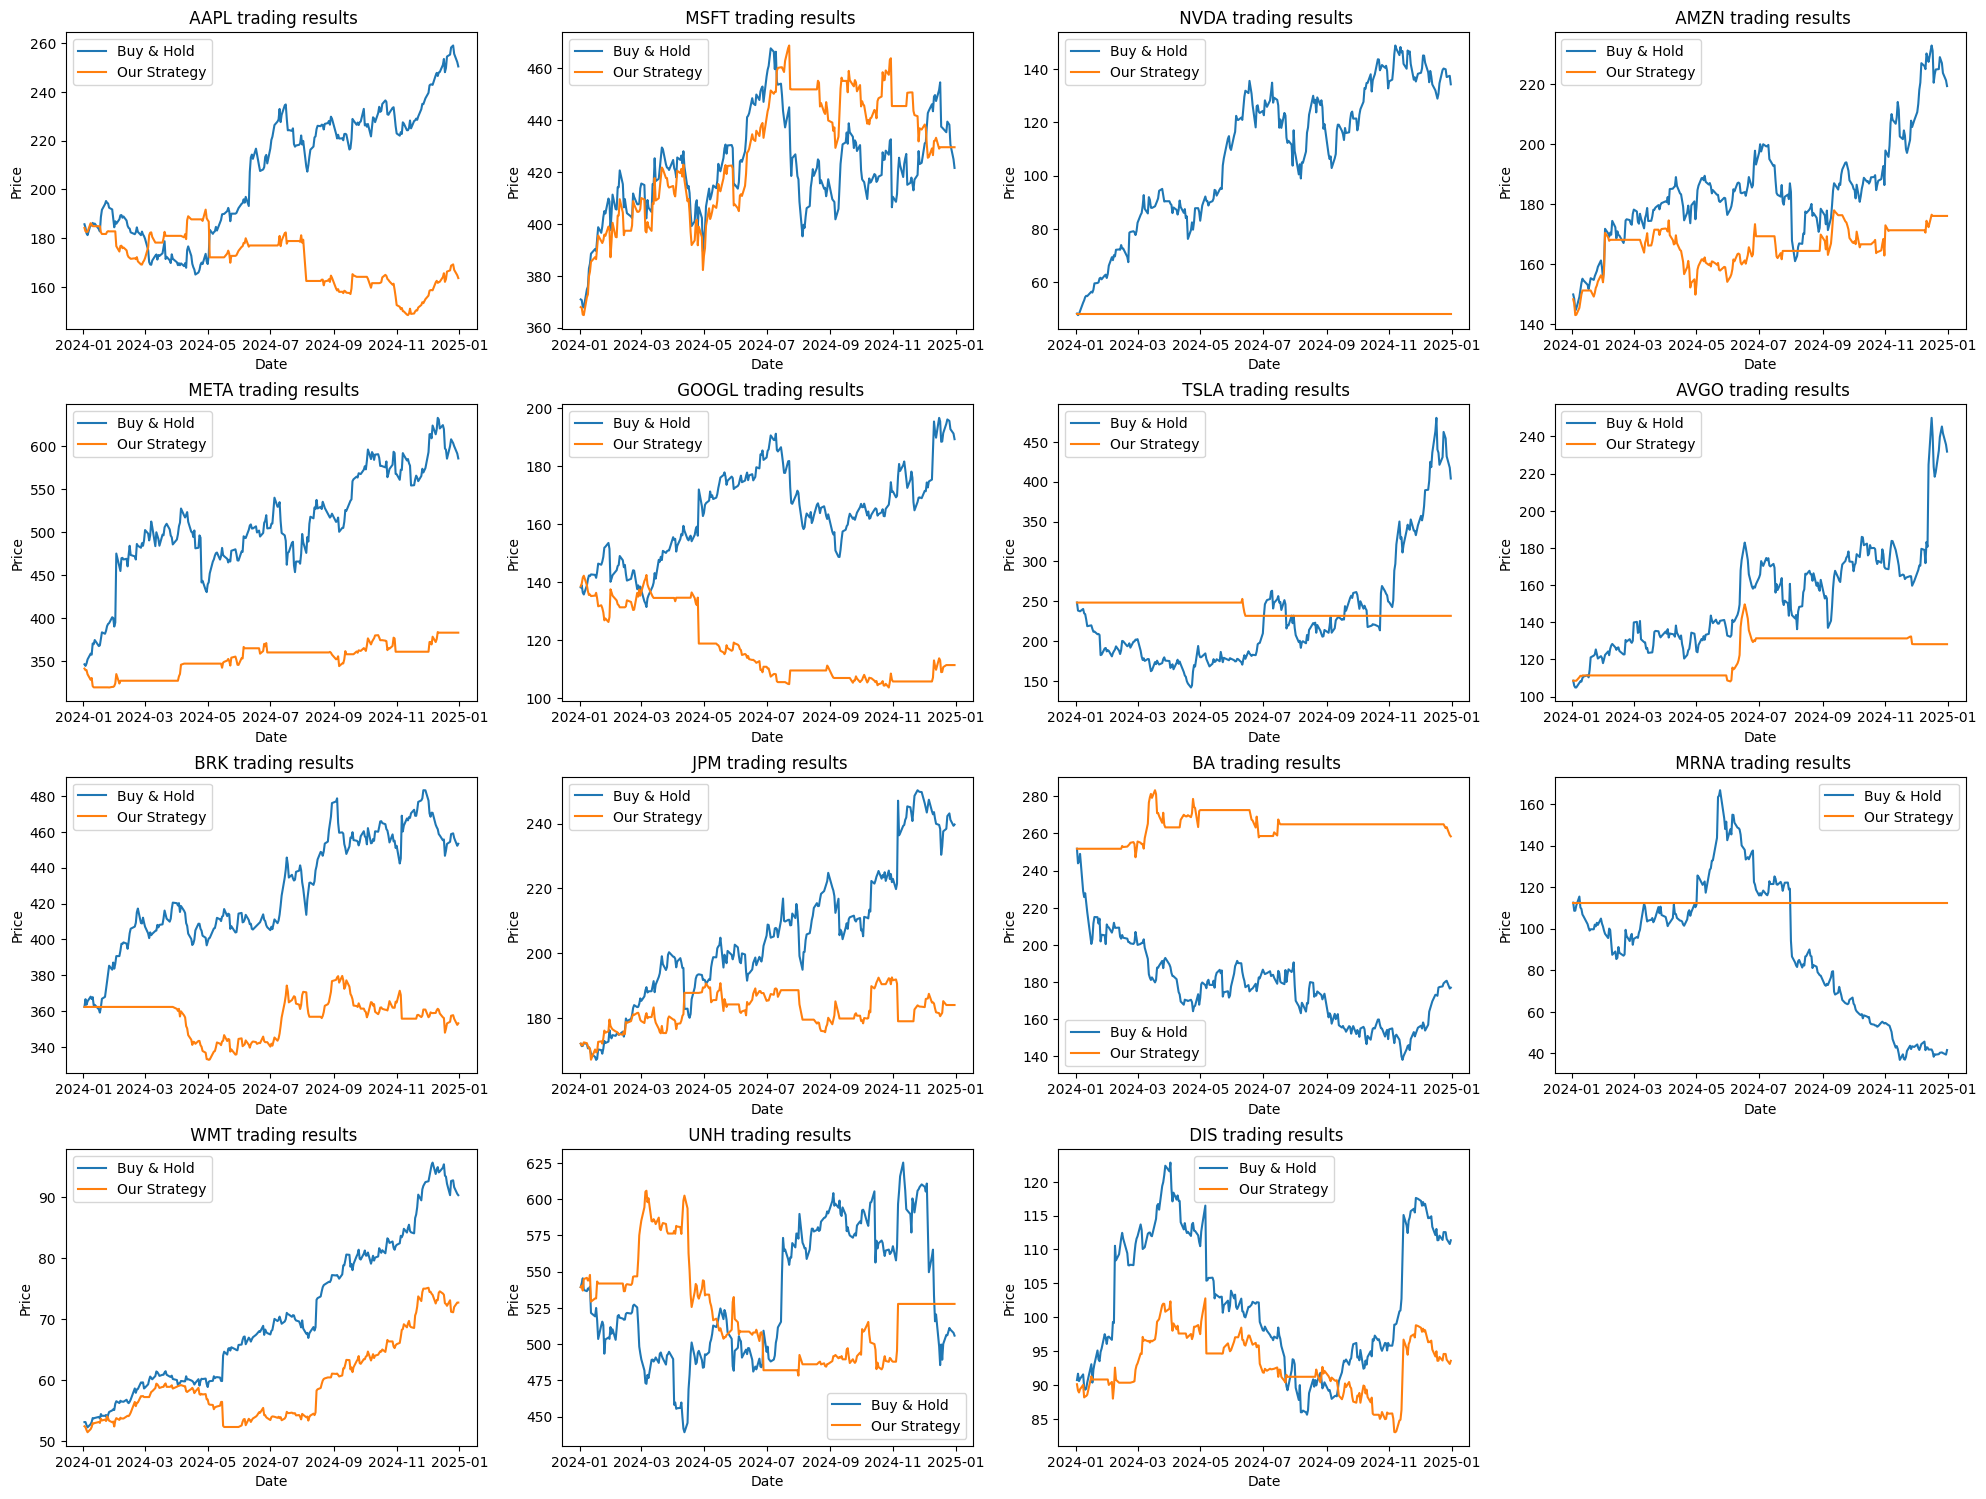

,accuracy,precision,ev,precision_ev,win B&H
第1次,52.79%,60.00%,0.001525,0.005502,0.27
總和,52.79%,60.00%,0.001525,0.005502,0.27


In [25]:
from usable_volatitlity import UsableVolatility

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "VIX": "low",
                "run_count" : str(i)
            }
            # print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = UsableVolatility(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            
            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])
            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        # plot fig
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
        # show stock results
        stock_avg = cacl_avg(pd.DataFrame(list_stock).loc[:, selected_columns])
        stock_avg.index = [stock[0]]
        stock_avg['win B&H'] = "yes" if list_stag_balance[-1] > list_bnh_rtn[-1] else "no"
        display(stock_avg.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn', 'win B&H']])
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-5-1 Volatility dicide stock

1
VIX too high
VIX too high
VIX too high


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
2317,0.625,0.666667,0.053006,0.07155,8,4,2,1,1,yes


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
2330,0.627907,0.740741,0.01876,0.02992,43,20,7,7,9,yes


VIX too high
VIX too high
VIX too high


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
2382,0.4,0.428571,0.008274,0.013929,10,3,4,1,2,no


...

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
BA,0.545455,0.4375,-0.0022,-0.007271,44,7,9,17,11,yes


VIX too high
VIX too high
VIX too high
VIX too high


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
WMT,0.529412,0.558824,0.000414,0.003997,68,19,15,17,17,no


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
UNH,0.528302,0.5,-0.000522,-0.005116,53,9,9,19,16,yes


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
DIS,0.508475,0.53125,-0.003881,0.000127,59,17,15,13,14,no


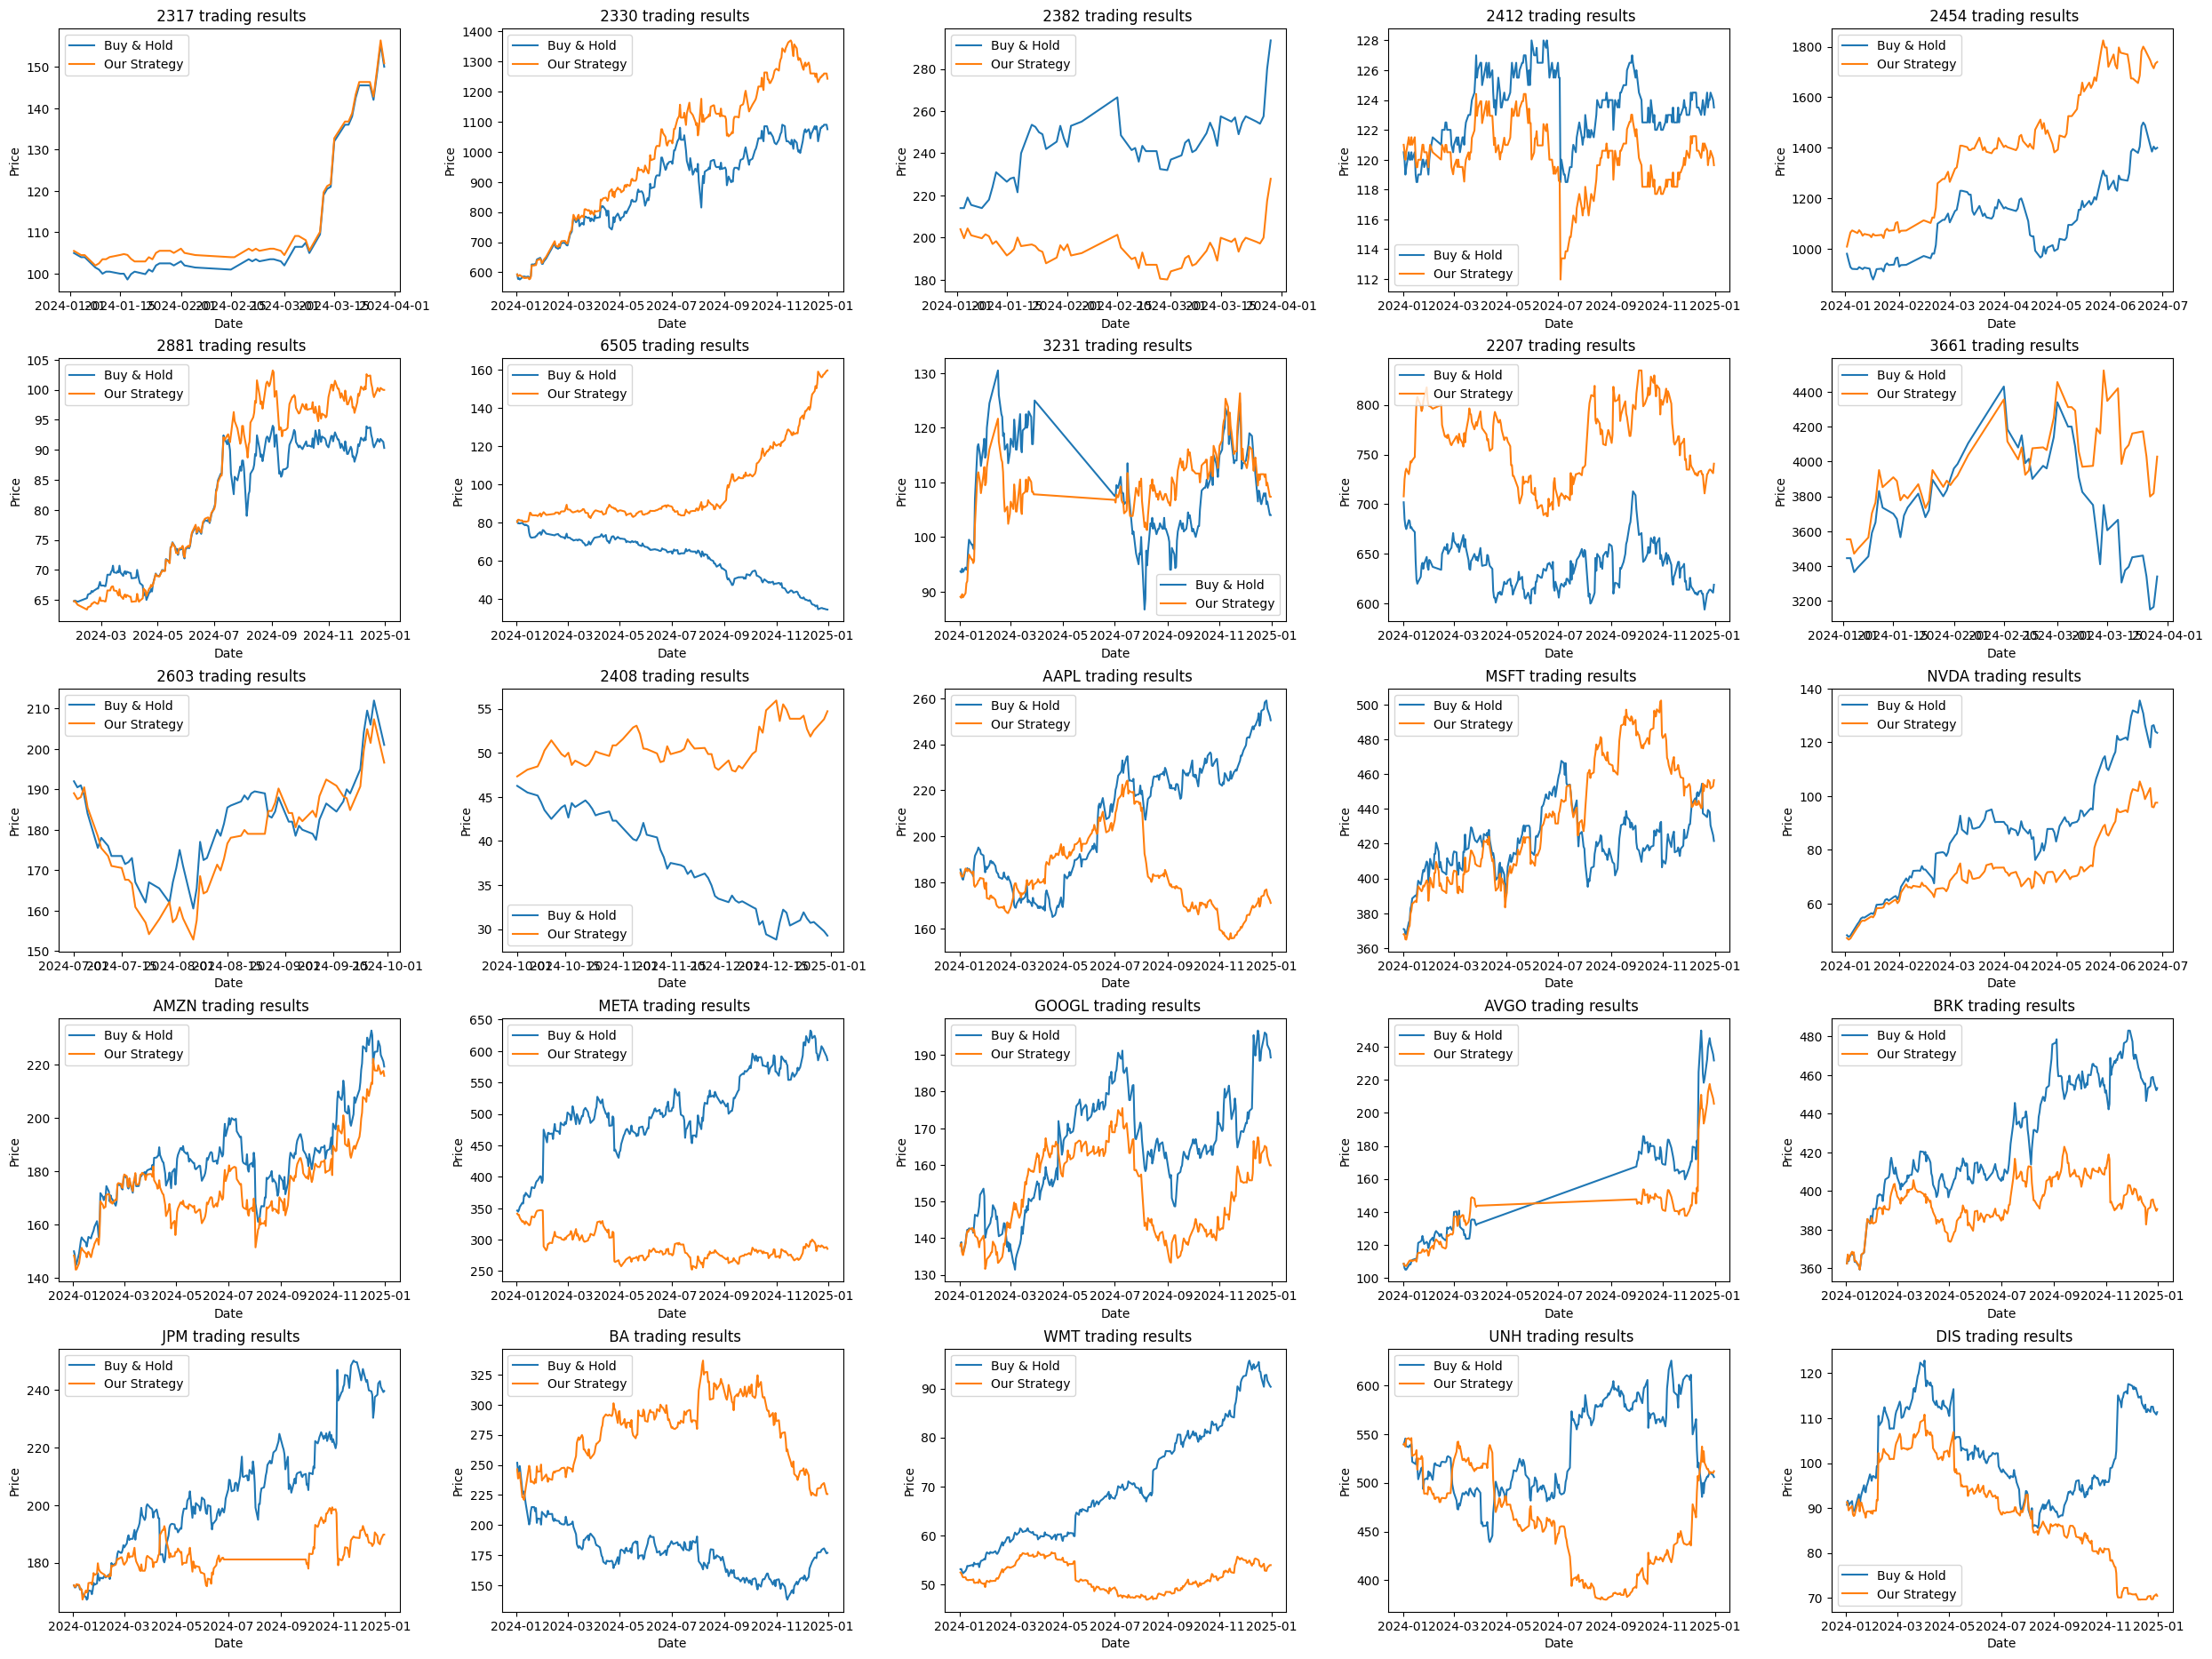

,accuracy,precision,ev,precision_ev,win B&H
第1次,52.33%,52.55%,0.005984,0.009132,0.48
總和,52.33%,52.55%,0.005984,0.009132,0.48


In [55]:
from usable_on import UsableFactorON

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in data:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            # print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = UsableFactorON(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            price_his = eval_module.get_price_his()

            last_key = list(train_datarange.keys())[-1]
            VIX = price_his.loc[price_his['Date'] == last_key, 'Volatility']
            if float(VIX.iloc[0]) > 0.3:
                print("VIX too high")
                continue
            
            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])
            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        # plot fig
        if len(list_stag_rtn) == 0:
            continue
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
        # show stock results
        stock_avg = cacl_avg(pd.DataFrame(list_stock).loc[:, selected_columns])
        stock_avg.index = [stock[0]]
        stock_avg['win B&H'] = "yes" if list_stag_balance[-1] > list_bnh_rtn[-1] else "no"
        display(stock_avg.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn', 'win B&H']])
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(1):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])

# 7-6 Index - Factor Usable Mix

1
twii 台灣指數期貨 tw 2022Q1
空頭做當沖
twii 台灣指數期貨 tw 2022Q2
空頭做當沖
twii 台灣指數期貨 tw 2022Q3
空頭做當沖
twii 台灣指數期貨 tw 2022Q4
多頭做過夜
twii 台灣指數期貨 tw 2023Q1
多頭做過夜
twii 台灣指數期貨 tw 2023Q2
多頭做過夜
twii 台灣指數期貨 tw 2023Q3
空頭做當沖
twii 台灣指數期貨 tw 2023Q4
多頭做過夜
twii 台灣指數期貨 tw 2024Q1
多頭做過夜
twii 台灣指數期貨 tw 2024Q2
多頭做過夜
twii 台灣指數期貨 tw 2024Q3
多頭做過夜
twii 台灣指數期貨 tw 2024Q4
多頭做過夜


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
0,0.543860,0.593750,0.001341,0.000795,57,19,13,12,13,NaN
1,0.516129,0.333333,-0.000413,-0.003921,62,7,14,25,16,NaN
2,0.461538,0.440000,0.001061,-0.000065,65,11,14,19,21,NaN
3,0.571429,0.555556,0.001403,0.007018,21,5,4,7,5,NaN
4,0.588235,0.750000,-0.000600,0.005122,17,6,2,4,5,NaN
5,0.800000,0.750000,0.013593,0.013970,5,3,1,1,0,NaN
6,0.587302,0.576923,0.001081,0.000300,63,30,22,7,4,NaN
7,0.600000,0.714286,0.007967,0.010992,10,5,2,1,2,NaN
8,0.500000,0.625000,0.010748,0.016207,12,5,3,1,3,NaN
9,0.818182,1.000000,0.017708,0.000000,11,7,0,2,2,NaN


spx S&P 500 us 2022Q1
空頭做當沖
spx S&P 500 us 2022Q2
空頭做當沖
spx S&P 500 us 2022Q3
空頭做當沖
spx S&P 500 us 2022Q4
空頭做當沖
spx S&P 500 us 2023Q1
多頭做過夜
spx S&P 500 us 2023Q2
多頭做過夜
spx S&P 500 us 2023Q3
多頭做過夜
spx S&P 500 us 2023Q4
多頭做過夜
spx S&P 500 us 2024Q1
多頭做過夜
spx S&P 500 us 2024Q2
多頭做過夜
spx S&P 500 us 2024Q3
多頭做過夜
spx S&P 500 us 2024Q4
多頭做過夜


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
0,0.500000,0.483871,-0.000076,-0.000350,64,30,32,2,0,NaN
1,0.412698,0.407407,-0.001765,-0.002281,63,22,32,4,5,NaN
2,0.492063,0.500000,-0.000206,-0.000112,63,30,30,1,2,NaN
3,0.462963,0.479167,-0.000536,-0.000066,54,23,25,2,4,NaN
4,0.600000,0.600000,0.018107,0.018107,5,3,2,0,0,NaN
5,1.000000,1.000000,0.000000,0.000000,1,1,0,0,0,NaN
6,0.000000,0.000000,0.000000,0.000000,4,0,3,1,0,NaN
7,1.000000,1.000000,0.000000,0.000000,3,3,0,0,0,NaN
8,0.777778,0.714286,0.010767,0.013148,9,5,2,2,0,NaN
9,0.400000,0.666667,0.006336,0.017136,5,2,1,0,2,NaN


2
twii 台灣指數期貨 tw 2022Q1
空頭做當沖
twii 台灣指數期貨 tw 2022Q2
空頭做當沖
twii 台灣指數期貨 tw 2022Q3
空頭做當沖
twii 台灣指數期貨 tw 2022Q4
多頭做過夜
twii 台灣指數期貨 tw 2023Q1
多頭做過夜
twii 台灣指數期貨 tw 2023Q2
多頭做過夜
twii 台灣指數期貨 tw 2023Q3
空頭做當沖
twii 台灣指數期貨 tw 2023Q4
多頭做過夜
twii 台灣指數期貨 tw 2024Q1
多頭做過夜
twii 台灣指數期貨 tw 2024Q2
多頭做過夜
twii 台灣指數期貨 tw 2024Q3
多頭做過夜
twii 台灣指數期貨 tw 2024Q4
多頭做過夜


...

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
0,0.500000,0.483871,-0.000076,-0.000350,64,30,32,2,0,NaN
1,0.403226,0.407407,-0.002182,-0.002281,62,22,32,3,5,NaN
2,0.484375,0.500000,-0.000300,-0.000112,64,30,30,1,3,NaN
3,0.483333,0.480769,0.000493,0.000800,60,25,27,4,4,NaN
4,0.666667,0.800000,0.006985,0.012957,6,4,1,0,1,NaN
5,1.000000,1.000000,0.000000,0.000000,1,1,0,0,0,NaN
6,0.666667,0.500000,-0.012407,-0.019470,3,1,1,1,0,NaN
7,1.000000,1.000000,0.000000,0.000000,4,4,0,0,0,NaN
8,0.625000,0.714286,0.013649,0.016279,8,5,2,0,1,NaN
9,0.333333,0.333333,0.013453,0.013453,3,1,2,0,0,NaN


10
twii 台灣指數期貨 tw 2022Q1
空頭做當沖
twii 台灣指數期貨 tw 2022Q2
空頭做當沖
twii 台灣指數期貨 tw 2022Q3
空頭做當沖
twii 台灣指數期貨 tw 2022Q4
多頭做過夜
twii 台灣指數期貨 tw 2023Q1
多頭做過夜
twii 台灣指數期貨 tw 2023Q2
多頭做過夜
twii 台灣指數期貨 tw 2023Q3
空頭做當沖
twii 台灣指數期貨 tw 2023Q4
多頭做過夜
twii 台灣指數期貨 tw 2024Q1
多頭做過夜
twii 台灣指數期貨 tw 2024Q2
多頭做過夜
twii 台灣指數期貨 tw 2024Q3
多頭做過夜
twii 台灣指數期貨 tw 2024Q4
多頭做過夜


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
0,0.578947,0.580000,0.000415,-0.000020,57,29,21,4,3,NaN
1,0.548387,0.307692,0.001293,-0.002265,62,4,9,30,19,NaN
2,0.531250,0.545455,0.001050,0.000117,64,12,10,22,20,NaN
3,0.555556,0.666667,-0.001238,0.010366,9,2,1,3,3,NaN
4,0.642857,0.857143,-0.000051,0.005808,14,6,1,3,4,NaN
5,0.833333,0.800000,0.012307,0.012351,6,4,1,1,0,NaN
6,0.571429,0.574468,0.001132,0.000367,63,27,20,9,7,NaN
7,0.714286,0.833333,0.012327,0.014738,7,5,1,0,1,NaN
8,0.555556,0.571429,0.014678,0.018610,9,4,3,1,1,NaN
9,0.833333,0.800000,0.032825,0.035673,6,4,1,1,0,NaN


spx S&P 500 us 2022Q1
空頭做當沖
spx S&P 500 us 2022Q2
空頭做當沖
spx S&P 500 us 2022Q3
空頭做當沖
spx S&P 500 us 2022Q4
空頭做當沖
spx S&P 500 us 2023Q1
多頭做過夜
spx S&P 500 us 2023Q2
多頭做過夜
spx S&P 500 us 2023Q3
多頭做過夜
spx S&P 500 us 2023Q4
多頭做過夜
spx S&P 500 us 2024Q1
多頭做過夜
spx S&P 500 us 2024Q2
多頭做過夜
spx S&P 500 us 2024Q3
多頭做過夜
spx S&P 500 us 2024Q4
多頭做過夜


,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn,win B&H
0,0.500000,0.483871,-0.000076,-0.000350,64,30,32,2,0,NaN
1,0.423729,0.423077,-0.001680,-0.001801,59,22,30,3,4,NaN
2,0.500000,0.508475,0.000092,0.000109,62,30,29,1,2,NaN
3,0.467742,0.462963,0.000101,0.000497,62,25,29,4,4,NaN
4,0.666667,0.666667,0.028526,0.028526,3,2,1,0,0,NaN
5,1.000000,1.000000,0.000000,0.000000,1,1,0,0,0,NaN
6,0.500000,0.500000,-0.020611,-0.020611,2,1,1,0,0,NaN
7,1.000000,1.000000,0.000000,0.000000,3,3,0,0,0,NaN
8,0.600000,0.666667,0.009414,0.010990,10,6,3,0,1,NaN
9,0.400000,0.666667,0.006336,0.017136,5,2,1,0,2,NaN


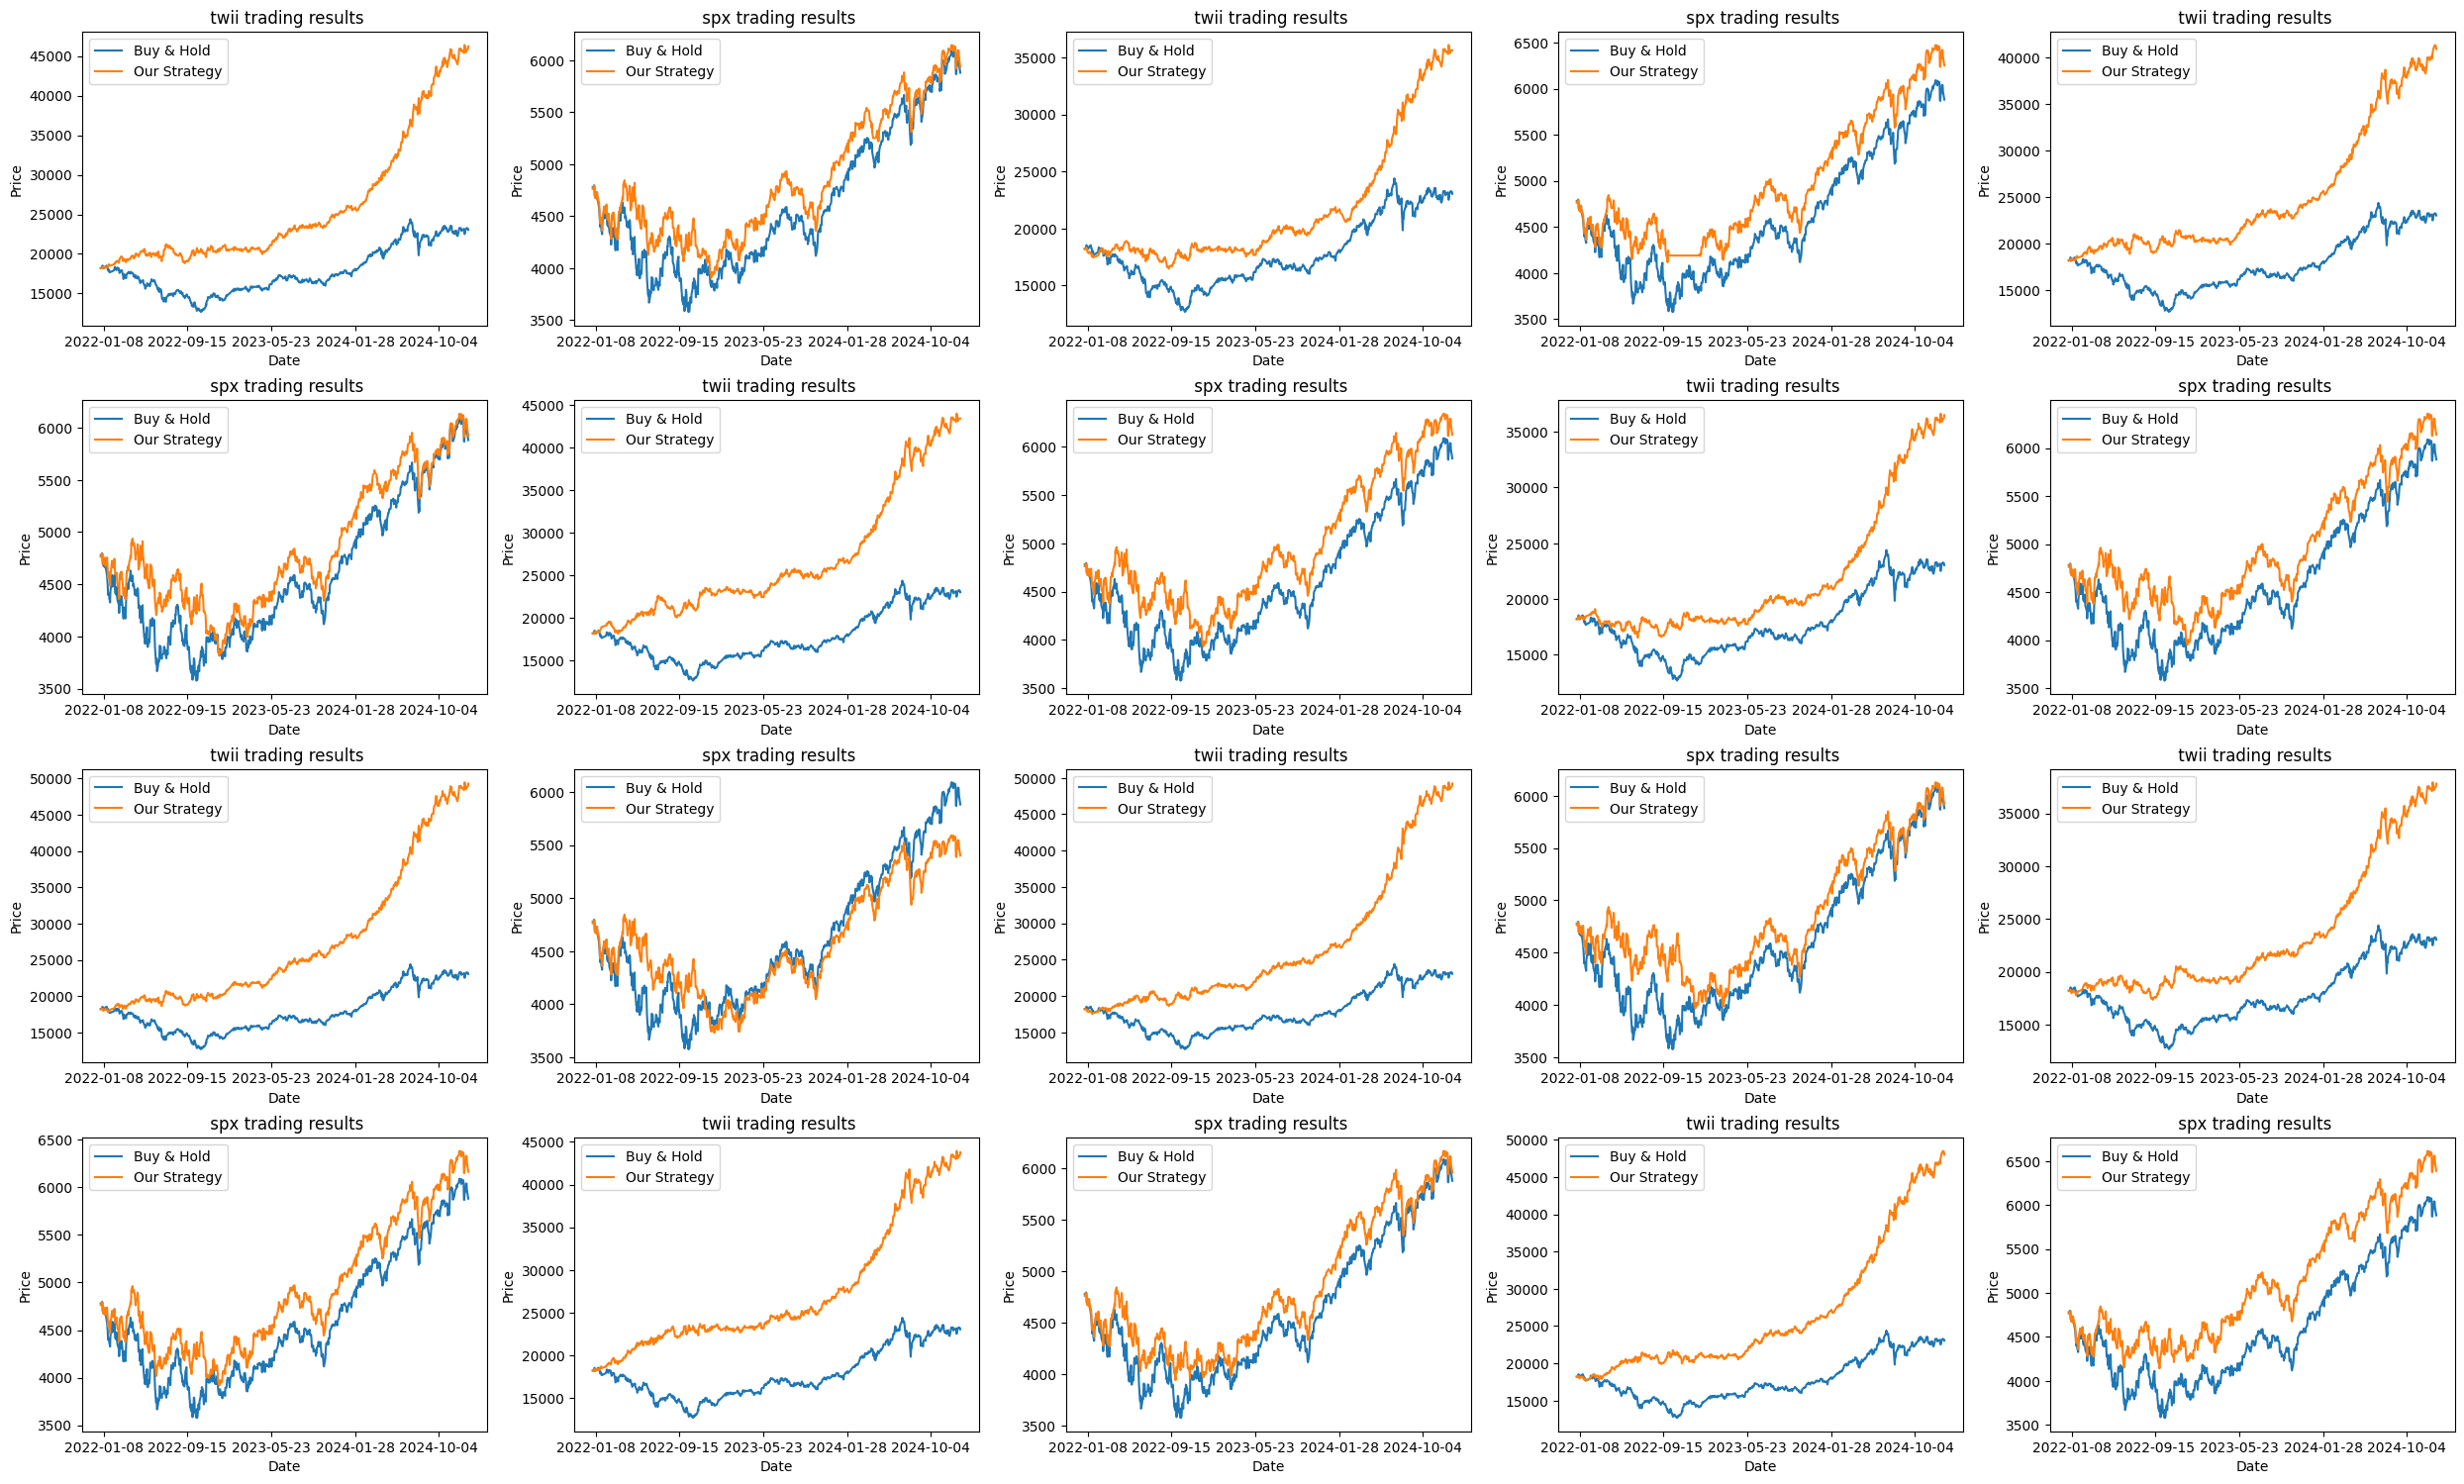

,accuracy,precision,ev,precision_ev,win B&H
第1次,52.08%,52.04%,0.001724,0.001493,1.00
第2次,53.29%,53.51%,0.001527,0.001309,1.00
第3次,52.70%,52.19%,0.001463,0.001613,1.00
第4次,51.53%,51.85%,0.001599,0.001740,1.00
第5次,52.42%,52.62%,0.001419,0.001018,1.00
第6次,54.17%,54.05%,0.001645,0.001378,0.50
第7次,52.67%,53.12%,0.001841,0.001499,1.00
第8次,51.93%,52.12%,0.001393,0.001078,1.00
第9次,53.24%,53.50%,0.001569,0.001387,1.00
第10次,53.86%,53.35%,0.001909,0.002007,1.00


In [38]:
from usable_mix_index import Index_UsableFactorMix

avgs = pd.DataFrame()
all_plots = []
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']

def runAll(i):
    stock_results = []
    index = []
    wincount = 0
    ttl_count = 0
    for stock in market_index:
        list_stock = []
        list_date, list_bnh_rtn, list_stag_rtn  = [], [], []
        for date_range in date_ranges:
            env = {
                "stock_id" : stock[0],
                "stock_name" : stock[1],
                "country" : stock[2],
                "components" : stock[3],
                "start_date" : date_range[0],
                "end_date" : date_range[1],
                "run_count" : str(i)
            }
            print(env['stock_id'], env['stock_name'], env['country'], date_range[2])

            eval_module = Index_UsableFactorMix(env)
            eval_module.run()
            train_datarange, test_datarange = eval_module.split_exp()
            
            mode = 1
            df = eval_module.training(mode, train_datarange, test_datarange)
            # display(df.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'tp', 'fp', 'tn', 'fn']])

            result = eval_module.get_result(mode)
            index.append(f"{stock[0]} - {date_range[2]}")
            stock_results.append(result["test"])
            list_stock.append(result["test"])

            l_date, l_bnh_rtn, l_stag_rtn = eval_module.get_return_list()
            # print(len(l_date), len(l_bnh_rtn), len(l_stag_rtn))
            list_date.extend(l_date)
            list_bnh_rtn.extend(l_bnh_rtn)
            list_stag_rtn.extend(l_stag_rtn)
            # print(len(list_date), len(list_bnh_rtn), len(list_stag_rtn))
            
        # plot fig
        list_stag_balance = get_balance_list(list_stag_rtn, list_bnh_rtn[0])
        ttl_count += 1
        if list_stag_balance[-1] > list_bnh_rtn[-1]:
            wincount += 1
        dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]
        fig, ax = plt.subplots()
        ax.set_title(f" {env['stock_id']} trading results")
        ax.plot(dplot, list_bnh_rtn, label="Buy & Hold")  # blue
        ax.plot(dplot, list_stag_balance, label="Our Strategy")  # orange
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        all_plots.append(fig)
        plt.close(fig)  # 關閉圖形，避免顯示
        
        # show stock results
        df_stock = pd.DataFrame(list_stock).loc[:, selected_columns]
        stock_avg = cacl_avg(df_stock)
        stock_avg.index = [stock[0]]
        stock_avg['win B&H'] = "yes" if list_stag_balance[-1] > list_bnh_rtn[-1] else "no"
        stock_avg = pd.concat([df_stock, stock_avg])
        display(stock_avg.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn', 'win B&H']])
        
    # caculate average row for this run
    df_stocks_results = pd.DataFrame(stock_results, index=index).loc[:, selected_columns]
    average_row = cacl_avg(df_stocks_results, wincount, ttl_count)
    average_row.index = ['第' + str(i) + '次']
    return average_row

for i in range(10):
    print(i+1)
    avgs = pd.concat([avgs, runAll(i+1)])

display_all_plots(all_plots)

# show average row
final_averages = avgs.mean()
final_average_row = pd.DataFrame(final_averages).T
final_average_row.index = ['總和']
avgs = pd.concat([avgs, final_average_row])
avgs['accuracy'] = avgs['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
avgs['precision'] = avgs['precision'].apply(lambda x: f"{x * 100:.2f}%")
display(avgs.loc[:, ['accuracy', 'precision', 'ev', 'precision_ev', 'win B&H']])